In [1]:
import pandas as pd
from sqlalchemy import create_engine

username = "@username"
password = "@password"
host = "localhost"
port = "5432"
database = "OLIST_Project"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

print("Connected successfully")

Connected successfully


In [2]:
import os
path = r"C:\Users\User\Documents\OLIST project\Extracted"
os.listdir(path)

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [3]:
import pandas as pd

for file in os.listdir(path):

    if file.endswith(".csv"):

        table_name = os.path.splitext(file)[0]
        file_path = os.path.join(path, file)

        df = pd.read_csv(file_path, encoding='utf-8')

        print(f"\nLoading {table_name}")
        print(f"Rows: {len(df):,}")

        df.to_sql(
            table_name,
            engine,
            if_exists='replace',
            index=False
        )

        print(f"Uploaded {table_name}")


Loading olist_customers_dataset
Rows: 99,441
Uploaded olist_customers_dataset

Loading olist_geolocation_dataset
Rows: 1,000,163
Uploaded olist_geolocation_dataset

Loading olist_orders_dataset
Rows: 99,441
Uploaded olist_orders_dataset

Loading olist_order_items_dataset
Rows: 112,650
Uploaded olist_order_items_dataset

Loading olist_order_payments_dataset
Rows: 103,886
Uploaded olist_order_payments_dataset

Loading olist_order_reviews_dataset
Rows: 99,224
Uploaded olist_order_reviews_dataset

Loading olist_products_dataset
Rows: 32,951
Uploaded olist_products_dataset

Loading olist_sellers_dataset
Rows: 3,095
Uploaded olist_sellers_dataset

Loading product_category_name_translation
Rows: 71
Uploaded product_category_name_translation


In [4]:
print("Column names of the tables")
for file in os.listdir(path):
    file_path = os.path.join(path,file) 
    df = pd.read_csv(file_path)
    print(f"{os.path.splitext(file)[0]} : {df.columns.tolist()}")

Column names of the tables
olist_customers_dataset : ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
olist_geolocation_dataset : ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
olist_orders_dataset : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
olist_order_items_dataset : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
olist_order_payments_dataset : ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
olist_order_reviews_dataset : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
olist_products_dataset : ['product_id', 'product_category_name'

In [5]:
# data understanding

In [6]:
# olist_customers_dataset

In [7]:
Query = """SELECT COUNT(*) AS total_rows
FROM olist_customers_dataset;"""
df = pd.read_sql(Query, engine)
print(df)

Query = """SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_name = 'olist_customers_dataset';"""
df = pd.read_sql(Query, engine)
print(df)


Query = """SELECT
    COUNT(*) FILTER (WHERE customer_id IS NULL) AS customer_id_nulls,
    COUNT(*) FILTER (WHERE customer_unique_id IS NULL) AS customer_unique_id_nulls,
    COUNT(*) FILTER (WHERE customer_zip_code_prefix IS NULL) AS customer_zip_code_prefix_nulls,
    COUNT(*) FILTER (WHERE customer_city IS NULL) AS customer_city_nulls,
    COUNT(*) FILTER (WHERE customer_state IS NULL) AS customer_state_nulls
FROM olist_customers_dataset;"""
df = pd.read_sql(Query, engine).T
print(df)

Query = """SELECT
    COUNT(DISTINCT customer_id) AS customer_id_unique,
    COUNT(DISTINCT customer_unique_id) AS customer_unique_id_unique,
    COUNT(DISTINCT customer_zip_code_prefix) AS customer_zip_code_prefix_unique,
    COUNT(DISTINCT customer_city) AS customer_city_unique,
    COUNT(DISTINCT customer_state) AS customer_state_unique
FROM olist_customers_dataset;"""

df = pd.read_sql(Query, engine).T
print(df)

   total_rows
0       99441
                column_name data_type
0  customer_zip_code_prefix    bigint
1               customer_id      text
2        customer_unique_id      text
3             customer_city      text
4            customer_state      text
                                0
customer_id_nulls               0
customer_unique_id_nulls        0
customer_zip_code_prefix_nulls  0
customer_city_nulls             0
customer_state_nulls            0
                                     0
customer_id_unique               99441
customer_unique_id_unique        96096
customer_zip_code_prefix_unique  14994
customer_city_unique              4119
customer_state_unique               27


In [8]:
# olist_geolocation_dataset : ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

In [9]:
Query = """SELECT COUNT(*) AS total_rows
FROM olist_geolocation_dataset;"""
df = pd.read_sql(Query, engine)
print(df)

Query = """SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_name = 'olist_geolocation_dataset';"""
df = pd.read_sql(Query, engine)
print(df)

Query = """SELECT
    COUNT(*) FILTER (WHERE geolocation_zip_code_prefix IS NULL) AS geolocation_zip_code_prefix_nulls,
    COUNT(*) FILTER (WHERE geolocation_lat IS NULL) AS geolocation_lat_nulls,
    COUNT(*) FILTER (WHERE geolocation_lng IS NULL) AS geolocation_lng_nulls,
    COUNT(*) FILTER (WHERE geolocation_city IS NULL) AS geolocation_city_nulls,
    COUNT(*) FILTER (WHERE geolocation_state IS NULL) AS geolocation_state_nulls
FROM olist_geolocation_dataset;"""
df = pd.read_sql(Query, engine).T
print(df)

Query = """SELECT
    COUNT(DISTINCT geolocation_zip_code_prefix) AS geolocation_zip_code_prefix_unique,
    COUNT(DISTINCT geolocation_lat) AS geolocation_lat_unique,
    COUNT(DISTINCT geolocation_lng) AS geolocation_lng_unique,
    COUNT(DISTINCT geolocation_city) AS geolocation_city_unique,
    COUNT(DISTINCT geolocation_state) AS geolocation_state_unique
FROM olist_geolocation_dataset;"""

df = pd.read_sql(Query, engine).T
print(df)

   total_rows
0     1000163
                   column_name         data_type
0  geolocation_zip_code_prefix            bigint
1              geolocation_lat  double precision
2              geolocation_lng  double precision
3             geolocation_city              text
4            geolocation_state              text
                                   0
geolocation_zip_code_prefix_nulls  0
geolocation_lat_nulls              0
geolocation_lng_nulls              0
geolocation_city_nulls             0
geolocation_state_nulls            0
                                         0
geolocation_zip_code_prefix_unique   19015
geolocation_lat_unique              717360
geolocation_lng_unique              717613
geolocation_city_unique               8011
geolocation_state_unique                27


In [10]:
# olist_orders_dataset : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

In [11]:
Query = """
SELECT COUNT(*) AS total_rows
FROM olist_orders_dataset;
"""
df = pd.read_sql(Query, engine)
print(df)

Query = """
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_name = 'olist_orders_dataset';
"""

df = pd.read_sql(Query, engine)
print(df)


Query = """
SELECT
    COUNT(*) FILTER (WHERE order_id IS NULL) AS order_id_nulls,
    COUNT(*) FILTER (WHERE customer_id IS NULL) AS customer_id_nulls,
    COUNT(*) FILTER (WHERE order_status IS NULL) AS order_status_nulls,
    COUNT(*) FILTER (WHERE order_purchase_timestamp IS NULL) AS order_purchase_timestamp_nulls,
    COUNT(*) FILTER (WHERE order_approved_at IS NULL) AS order_approved_at_nulls,
    COUNT(*) FILTER (WHERE order_delivered_carrier_date IS NULL) AS order_delivered_carrier_date_nulls,
    COUNT(*) FILTER (WHERE order_delivered_customer_date IS NULL) AS order_delivered_customer_date_nulls,
    COUNT(*) FILTER (WHERE order_estimated_delivery_date IS NULL) AS order_estimated_delivery_date_nulls
FROM olist_orders_dataset;
"""

df = pd.read_sql(Query, engine).T
print(df)

Query = """
SELECT
    COUNT(DISTINCT order_id) AS order_id_unique,
    COUNT(DISTINCT customer_id) AS customer_id_unique,
    COUNT(DISTINCT order_status) AS order_status_unique,
    COUNT(DISTINCT order_purchase_timestamp) AS order_purchase_timestamp_unique,
    COUNT(DISTINCT order_approved_at) AS order_approved_at_unique,
    COUNT(DISTINCT order_delivered_carrier_date) AS order_delivered_carrier_date_unique,
    COUNT(DISTINCT order_delivered_customer_date) AS order_delivered_customer_date_unique,
    COUNT(DISTINCT order_estimated_delivery_date) AS order_estimated_delivery_date_unique
FROM olist_orders_dataset;
"""

df = pd.read_sql(Query, engine).T
print(df)

   total_rows
0       99441
                     column_name data_type
0                       order_id      text
1                    customer_id      text
2                   order_status      text
3       order_purchase_timestamp      text
4              order_approved_at      text
5   order_delivered_carrier_date      text
6  order_delivered_customer_date      text
7  order_estimated_delivery_date      text
                                        0
order_id_nulls                          0
customer_id_nulls                       0
order_status_nulls                      0
order_purchase_timestamp_nulls          0
order_approved_at_nulls               160
order_delivered_carrier_date_nulls   1783
order_delivered_customer_date_nulls  2965
order_estimated_delivery_date_nulls     0
                                          0
order_id_unique                       99441
customer_id_unique                    99441
order_status_unique                       8
order_purchase_timestamp_unique

In [12]:
# olist_order_items_dataset : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

In [13]:
Query = """
SELECT COUNT(*) AS total_rows
FROM olist_order_items_dataset;
"""

df = pd.read_sql(Query, engine)
print(df)


Query = """
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_name = 'olist_order_items_dataset'
ORDER BY ordinal_position;
"""

df = pd.read_sql(Query, engine)
print(df)


Query = """
SELECT
    COUNT(*) FILTER (WHERE order_id IS NULL) AS order_id_nulls,
    COUNT(*) FILTER (WHERE order_item_id IS NULL) AS order_item_id_nulls,
    COUNT(*) FILTER (WHERE product_id IS NULL) AS product_id_nulls,
    COUNT(*) FILTER (WHERE seller_id IS NULL) AS seller_id_nulls,
    COUNT(*) FILTER (WHERE shipping_limit_date IS NULL) AS shipping_limit_date_nulls,
    COUNT(*) FILTER (WHERE price IS NULL) AS price_nulls,
    COUNT(*) FILTER (WHERE freight_value IS NULL) AS freight_value_nulls
FROM olist_order_items_dataset;
"""

df = pd.read_sql(Query, engine).T
print(df)

Query = """
SELECT
    COUNT(DISTINCT order_id) AS order_id_unique,
    COUNT(DISTINCT order_item_id) AS order_item_id_unique,
    COUNT(DISTINCT product_id) AS product_id_unique,
    COUNT(DISTINCT seller_id) AS seller_id_unique,
    COUNT(DISTINCT shipping_limit_date) AS shipping_limit_date_unique,
    COUNT(DISTINCT price) AS price_unique,
    COUNT(DISTINCT freight_value) AS freight_value_unique
FROM olist_order_items_dataset;
"""

df = pd.read_sql(Query, engine).T
print(df)

   total_rows
0      112650
           column_name         data_type
0             order_id              text
1        order_item_id            bigint
2           product_id              text
3            seller_id              text
4  shipping_limit_date              text
5                price  double precision
6        freight_value  double precision
                           0
order_id_nulls             0
order_item_id_nulls        0
product_id_nulls           0
seller_id_nulls            0
shipping_limit_date_nulls  0
price_nulls                0
freight_value_nulls        0
                                0
order_id_unique             98666
order_item_id_unique           21
product_id_unique           32951
seller_id_unique             3095
shipping_limit_date_unique  93318
price_unique                 5968
freight_value_unique         6999


In [14]:
# olist_order_payments_dataset : ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

In [15]:
Query = """
SELECT COUNT(*) AS total_rows
FROM olist_order_payments_dataset;
"""

df = pd.read_sql(Query, engine)
print(df)


Query = """
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_name = 'olist_order_payments_dataset'
ORDER BY ordinal_position;
"""

df = pd.read_sql(Query, engine)
print(df)


Query = """
SELECT
    COUNT(*) FILTER (WHERE order_id IS NULL) AS order_id_nulls,
    COUNT(*) FILTER (WHERE payment_sequential IS NULL) AS payment_sequential_nulls,
    COUNT(*) FILTER (WHERE payment_type IS NULL) AS payment_type_nulls,
    COUNT(*) FILTER (WHERE payment_installments IS NULL) AS payment_installments_nulls,
    COUNT(*) FILTER (WHERE payment_value IS NULL) AS payment_value_nulls
FROM olist_order_payments_dataset;
"""

df = pd.read_sql(Query, engine).T
print(df)

Query = """
SELECT
    COUNT(DISTINCT order_id) AS order_id_unique,
    COUNT(DISTINCT payment_sequential) AS payment_sequential_unique,
    COUNT(DISTINCT payment_type) AS payment_type_unique,
    COUNT(DISTINCT payment_installments) AS payment_installments_unique,
    COUNT(DISTINCT payment_value) AS payment_value_unique
FROM olist_order_payments_dataset;
"""

df = pd.read_sql(Query, engine).T
print(df)

   total_rows
0      103886
            column_name         data_type
0              order_id              text
1    payment_sequential            bigint
2          payment_type              text
3  payment_installments            bigint
4         payment_value  double precision
                            0
order_id_nulls              0
payment_sequential_nulls    0
payment_type_nulls          0
payment_installments_nulls  0
payment_value_nulls         0
                                 0
order_id_unique              99440
payment_sequential_unique       29
payment_type_unique              5
payment_installments_unique     24
payment_value_unique         29077


In [16]:
# olist_order_reviews_dataset : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

In [17]:
Query = """
SELECT COUNT(*) AS total_rows
FROM olist_order_reviews_dataset;
"""

df = pd.read_sql(Query, engine)
print(df)

Query = """
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_name = 'olist_order_reviews_dataset'
ORDER BY ordinal_position;
"""

df = pd.read_sql(Query, engine)
print(df)

Query = """
SELECT
    COUNT(*) FILTER (WHERE review_id IS NULL) AS review_id_nulls,
    COUNT(*) FILTER (WHERE order_id IS NULL) AS order_id_nulls,
    COUNT(*) FILTER (WHERE review_score IS NULL) AS review_score_nulls,
    COUNT(*) FILTER (WHERE review_comment_title IS NULL) AS review_comment_title_nulls,
    COUNT(*) FILTER (WHERE review_comment_message IS NULL) AS review_comment_message_nulls,
    COUNT(*) FILTER (WHERE review_creation_date IS NULL) AS review_creation_date_nulls,
    COUNT(*) FILTER (WHERE review_answer_timestamp IS NULL) AS review_answer_timestamp_nulls
FROM olist_order_reviews_dataset;
"""

df = pd.read_sql(Query, engine).T
print(df)

Query = """
SELECT
    COUNT(DISTINCT review_id) AS review_id_unique,
    COUNT(DISTINCT order_id) AS order_id_unique,
    COUNT(DISTINCT review_score) AS review_score_unique,
    COUNT(DISTINCT review_comment_title) AS review_comment_title_unique,
    COUNT(DISTINCT review_comment_message) AS review_comment_message_unique,
    COUNT(DISTINCT review_creation_date) AS review_creation_date_unique,
    COUNT(DISTINCT review_answer_timestamp) AS review_answer_timestamp_unique
FROM olist_order_reviews_dataset;
"""

df = pd.read_sql(Query, engine).T
print(df)

   total_rows
0       99224
               column_name data_type
0                review_id      text
1                 order_id      text
2             review_score    bigint
3     review_comment_title      text
4   review_comment_message      text
5     review_creation_date      text
6  review_answer_timestamp      text
                                   0
review_id_nulls                    0
order_id_nulls                     0
review_score_nulls                 0
review_comment_title_nulls     87656
review_comment_message_nulls   58247
review_creation_date_nulls         0
review_answer_timestamp_nulls      0
                                    0
review_id_unique                98410
order_id_unique                 98673
review_score_unique                 5
review_comment_title_unique      4527
review_comment_message_unique   36159
review_creation_date_unique       636
review_answer_timestamp_unique  98248


In [18]:
# olist_products_dataset : ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

In [19]:
Query = """
SELECT COUNT(*) AS total_rows
FROM olist_products_dataset;
"""

df = pd.read_sql(Query, engine)
print(df)

Query = """
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_name = 'olist_products_dataset'
ORDER BY ordinal_position;
"""

df = pd.read_sql(Query, engine)
print(df)

Query = """
SELECT
    COUNT(*) FILTER (WHERE product_id IS NULL) AS product_id_nulls,
    COUNT(*) FILTER (WHERE product_category_name IS NULL) AS product_category_name_nulls,
    COUNT(*) FILTER (WHERE product_name_lenght IS NULL) AS product_name_length_nulls,
    COUNT(*) FILTER (WHERE product_description_lenght IS NULL) AS product_description_length_nulls,
    COUNT(*) FILTER (WHERE product_photos_qty IS NULL) AS product_photos_qty_nulls,
    COUNT(*) FILTER (WHERE product_weight_g IS NULL) AS product_weight_g_nulls,
    COUNT(*) FILTER (WHERE product_length_cm IS NULL) AS product_length_cm_nulls,
    COUNT(*) FILTER (WHERE product_height_cm IS NULL) AS product_height_cm_nulls,
    COUNT(*) FILTER (WHERE product_width_cm IS NULL) AS product_width_cm_nulls
FROM olist_products_dataset;
"""

df = pd.read_sql(Query, engine).T
print(df)

Query = """
SELECT
    COUNT(DISTINCT product_id) AS product_id_unique,
    COUNT(DISTINCT product_category_name) AS product_category_name_unique,
    COUNT(DISTINCT product_name_lenght) AS product_name_length_unique,
    COUNT(DISTINCT product_description_lenght) AS product_description_length_unique,
    COUNT(DISTINCT product_photos_qty) AS product_photos_qty_unique,
    COUNT(DISTINCT product_weight_g) AS product_weight_g_unique,
    COUNT(DISTINCT product_length_cm) AS product_length_cm_unique,
    COUNT(DISTINCT product_height_cm) AS product_height_cm_unique,
    COUNT(DISTINCT product_width_cm) AS product_width_cm_unique
FROM olist_products_dataset;
"""

df = pd.read_sql(Query, engine).T
print(df)

   total_rows
0       32951
                  column_name         data_type
0                  product_id              text
1       product_category_name              text
2         product_name_lenght  double precision
3  product_description_lenght  double precision
4          product_photos_qty  double precision
5            product_weight_g  double precision
6           product_length_cm  double precision
7           product_height_cm  double precision
8            product_width_cm  double precision
                                    0
product_id_nulls                    0
product_category_name_nulls       610
product_name_length_nulls         610
product_description_length_nulls  610
product_photos_qty_nulls          610
product_weight_g_nulls              2
product_length_cm_nulls             2
product_height_cm_nulls             2
product_width_cm_nulls              2
                                       0
product_id_unique                  32951
product_category_name_unique  

In [20]:
# olist_sellers_dataset : ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

In [21]:
Query = """
SELECT COUNT(*) AS total_rows
FROM olist_sellers_dataset;
"""

df = pd.read_sql(Query, engine)
print(df)

Query = """
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_name = 'olist_sellers_dataset'
ORDER BY ordinal_position;
"""

df = pd.read_sql(Query, engine)
print(df)

Query = """
SELECT
    COUNT(*) FILTER (WHERE seller_id IS NULL) AS seller_id_nulls,
    COUNT(*) FILTER (WHERE seller_zip_code_prefix IS NULL) AS seller_zip_code_prefix_nulls,
    COUNT(*) FILTER (WHERE seller_city IS NULL) AS seller_city_nulls,
    COUNT(*) FILTER (WHERE seller_state IS NULL) AS seller_state_nulls
FROM olist_sellers_dataset;
"""

df = pd.read_sql(Query, engine).T
print(df)

Query = """
SELECT
    COUNT(DISTINCT seller_id) AS seller_id_unique,
    COUNT(DISTINCT seller_zip_code_prefix) AS seller_zip_code_prefix_unique,
    COUNT(DISTINCT seller_city) AS seller_city_unique,
    COUNT(DISTINCT seller_state) AS seller_state_unique
FROM olist_sellers_dataset;
"""

df = pd.read_sql(Query, engine).T
print(df)

   total_rows
0        3095
              column_name data_type
0               seller_id      text
1  seller_zip_code_prefix    bigint
2             seller_city      text
3            seller_state      text
                              0
seller_id_nulls               0
seller_zip_code_prefix_nulls  0
seller_city_nulls             0
seller_state_nulls            0
                                  0
seller_id_unique               3095
seller_zip_code_prefix_unique  2246
seller_city_unique              611
seller_state_unique              23


In [22]:
# product_category_name_translation : ['product_category_name', 'product_category_name_english']

In [23]:
Query = """
SELECT COUNT(*) AS total_rows
FROM product_category_name_translation;
"""

df = pd.read_sql(Query, engine)
print(df)

Query = """
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_name = 'product_category_name_translation'
ORDER BY ordinal_position;
"""

df = pd.read_sql(Query, engine)
print(df)

Query = """
SELECT
    COUNT(*) FILTER (WHERE product_category_name IS NULL) AS product_category_name_nulls,
    COUNT(*) FILTER (WHERE product_category_name_english IS NULL) AS product_category_name_english_nulls
FROM product_category_name_translation;
"""

df = pd.read_sql(Query, engine).T
print(df)

Query = """
SELECT
    COUNT(DISTINCT product_category_name) AS product_category_name_unique,
    COUNT(DISTINCT product_category_name_english) AS product_category_name_english_unique
FROM product_category_name_translation;
"""

df = pd.read_sql(Query, engine).T
print(df)

   total_rows
0          71
                     column_name data_type
0          product_category_name      text
1  product_category_name_english      text
                                     0
product_category_name_nulls          0
product_category_name_english_nulls  0
                                       0
product_category_name_unique          71
product_category_name_english_unique  71


In [24]:
# Table analysis

In [25]:
# Customer dataset

In [26]:
Query = """SELECT customer_id, customer_unique_id, CAST(customer_zip_code_prefix AS TEXT) AS customer_zip_code_prefix,
TRIM(LOWER(customer_city)) AS customer_city,
TRIM(UPPER(customer_state)) AS customer_state
FROM olist_customers_dataset;"""
df1 = pd.read_sql(Query, engine)
df1

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [27]:
# olist_geolocation_dataset

In [28]:
Query = """SELECT CAST(geolocation_zip_code_prefix AS TEXT) AS geolocation_zip_code_prefix , 
geolocation_lat, geolocation_lng, 
TRIM(LOWER(geolocation_city)) AS geological_city,
TRIM(UPPER(geolocation_state)) AS geological_state
FROM olist_geolocation_dataset"""
df2 = pd.read_sql(Query, engine)
df2

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geological_city,geological_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


In [29]:
# olist_orders_dataset

In [30]:
query = """SELECT order_status, COUNT(*) AS counts FROM olist_orders_dataset
GROUP BY order_status ORDER BY counts DESC"""
order_status_check = pd.read_sql(query, engine)
order_status_check

,order_status,counts
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [31]:
# data integrity check for order_status = delivered 
query = """SELECT COUNT(*), COUNT(order_approved_at),
COUNT(order_delivered_carrier_date), COUNT(order_delivered_customer_date)
FROM olist_orders_dataset
WHERE order_status = 'delivered';"""
check = pd.read_sql(query, engine)
check

,count,count,count,count
0,96478,96464,96476,96470


In [32]:
# DATA QUALITY ISSUE 
# 14 delivered orders have null approved date
# 2 delivered orders have null carrier delivered date
# 8 delivered orders have null customer delivery date

In [33]:
# the revenue analysis filter logic:
# Only delivered orders are included - other statuses mean that the rder didn't completedabs

In [34]:
Query = """SELECT order_id, customer_id, order_status, 
CAST(order_purchase_timestamp AS TIMESTAMP) AS order_purchase_timestamp,
CAST(order_approved_at AS TIMESTAMP) AS order_approved_at,
CAST(order_delivered_carrier_date AS TIMESTAMP) AS order_delivered_carrier_date, 
CAST(order_delivered_customer_date AS TIMESTAMP) AS order_delivered_customer_date,
CAST(order_estimated_delivery_date AS TIMESTAMP) AS order_estimated_delivery_date
FROM olist_orders_dataset"""

df3 = pd.read_sql(Query, engine)
df3

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [35]:
query = """SELECT MIN(CAST(order_purchase_timestamp AS TIMESTAMP)) AS first_purchase_date,
MAX(CAST(order_purchase_timestamp AS TIMESTAMP))  AS last_purchase_date
FROM olist_orders_dataset"""
p_dates_check = pd.read_sql(query, engine)
p_dates_check

,first_purchase_date,last_purchase_date
0,2016-09-04 21:15:19,2018-10-17 17:30:18


In [36]:
# Data validation check for delivered orders
# Checks that the dates are in correct order: purchase < approved < carrier < delivered
# Other statuses are excluded
# they are guranteed to  have null dates - not a data quality issue 
query = """SELECT COUNT(*) as logic_violations
FROM olist_orders_dataset
WHERE order_status = 'delivered'
AND order_approved_at IS NOT NULL
AND order_delivered_carrier_date IS NOT NULL
AND order_delivered_customer_date IS NOT NULL
AND(
CAST(order_purchase_timestamp AS TIMESTAMP) > CAST(order_approved_at AS TIMESTAMP)
OR CAST(order_approved_at AS TIMESTAMP) > CAST(order_delivered_carrier_date AS TIMESTAMP)
OR CAST(order_delivered_carrier_date AS TIMESTAMP) > CAST(order_delivered_customer_date AS TIMESTAMP)
)"""
check = pd.read_sql(query, engine)
check

,logic_violations
0,1373


In [37]:
# FINDING: 1373 deliverede orders have date logic violations
# These rows will be excluded from the revenue analysis with the NULL dates rows(in date analysis)

In [38]:
# olist_order_items_dataset : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

In [39]:
query = """SELECT COUNT(*) AS violations
FROM olist_order_items_dataset
WHERE order_item_id < 1"""
item_id_check = pd.read_sql(query, engine)
item_id_check

,violations
0,0


In [40]:
query = """SELECT COUNT(*) AS violations
FROM olist_order_items_dataset
WHERE price <= 0
OR freight_value < 0""" # frieght_value can be 0 due to free shipping
value_check = pd.read_sql(query, engine)
value_check

,violations
0,0


In [41]:
Query = """SELECT order_id, 
CAST(order_item_id AS TEXT) AS order_item_id,
product_id, seller_id, 
CAST(shipping_limit_date AS TIMESTAMP) AS shipping_limit_date, 
price, freight_value
FROM olist_order_items_dataset"""

df4 = pd.read_sql(Query, engine)
df4

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [42]:
# olist_order_payments_dataset : ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

In [43]:
query = """SELECT payment_type, COUNT(*) AS count
FROM olist_order_payments_dataset
GROUP BY payment_type
ORDER BY count DESC"""

pay_type_check = pd.read_sql(query, engine)
pay_type_check

,payment_type,count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


In [44]:
query = """SELECT COUNT(*) AS violations
FROM olist_order_payments_dataset
WHERE payment_value <= 0"""

pay_val_check = pd.read_sql(query, engine)
pay_val_check

,violations
0,9


In [45]:
query = """SELECT *
FROM olist_order_payments_dataset
WHERE payment_value <= 0"""

pay_val_check = pd.read_sql(query, engine)
pay_val_check

# DATA Quality issue

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
1,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
2,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
3,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
4,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
5,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
6,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
7,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
8,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [46]:
query = """SELECT COUNT(*) AS violations
FROM olist_order_payments_dataset
WHERE payment_installments < 1"""

pay_inst_check = pd.read_sql(query, engine)
pay_inst_check

,violations
0,2


In [47]:
query = """SELECT *
FROM olist_order_payments_dataset
WHERE payment_installments < 1"""

pay_inst_check = pd.read_sql(query, engine)
pay_inst_check

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
1,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [48]:
query = """SELECT payment_type, COUNT(*) 
FROM olist_order_payments_dataset
WHERE payment_installments > 1
GROUP BY payment_type"""
pay_inst_check = pd.read_sql(query, engine)
pay_inst_check

,payment_type,count
0,credit_card,51338


In [49]:
# sequential integrity per order
query = """WITH cte AS (SELECT order_id, 
MIN(payment_sequential) AS min_seq, 
MAX(payment_sequential) AS max_seq,
COUNT(*) AS total_rows_per_order
FROM olist_order_payments_dataset
GROUP BY order_id
HAVING MIN(payment_sequential) != 1 
OR MAX(payment_sequential) != COUNT(*))
SELECT COUNT(*) AS violations FROM cte"""
seq_int_check = pd.read_sql(query, engine)
seq_int_check

,violations
0,80


In [50]:
# 80 rows have gap in sequestion numbering

In [51]:
Query = """SELECT order_id, 
CAST(payment_sequential AS INT), payment_type, 
CAST(payment_installments AS INT), payment_value
FROM olist_order_payments_dataset"""

df5 = pd.read_sql(Query, engine)
df5

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [52]:
# olist_order_reviews_dataset : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

In [53]:
query = """SELECT review_score, COUNT(*) AS count_of_reviews
FROM olist_order_reviews_dataset
GROUP BY review_score
ORDER BY count_of_reviews DESC"""

review_score_check = pd.read_sql(query, engine)
review_score_check

,review_score,count_of_reviews
0,5,57328
1,4,19142
2,1,11424
3,3,8179
4,2,3151


In [54]:
query = """SELECT COUNT(*) AS violations
FROM olist_order_reviews_dataset
WHERE CAST(review_creation_date AS TIMESTAMP) > CAST(review_answer_timestamp AS TIMESTAMP)"""
date_check = pd.read_sql(query, engine)
date_check

,violations
0,0


In [55]:
# Review ID is not unique -- will check for full row duplicates, same review id different orders, same review ID same order Different values
# Key Columns for analysis: review_score, review_creation_date, review_answer_timestamp

In [56]:
query = """SELECT COUNT(*) AS full_duplicate_violation
FROM(SELECT *, COUNT(*)
FROM olist_order_reviews_dataset
GROUP BY review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp
HAVING COUNT(*)>1) AS  T"""
id_check = pd.read_sql(query, engine)
id_check

,full_duplicate_violation
0,0


In [57]:
# same review id different orders
query = """SELECT COUNT(*) AS violations
FROM(
SELECT review_id 
FROM olist_order_reviews_dataset
GROUP BY review_id
HAVING COUNT(DISTINCT order_id) > 1
) AS T"""
id_check = pd.read_sql(query, engine)
id_check

,violations
0,789


In [58]:
# same review ID same order Different values
query = """SELECT COUNT(*) AS violations
FROM (
    SELECT review_id, order_id
    FROM olist_order_reviews_dataset
    GROUP BY review_id, order_id
    HAVING COUNT(*) > 1
) AS T"""
id_check = pd.read_sql(query, engine)
id_check

,violations
0,0


In [59]:
# 789 review ids are mapped to multiple order ids (come with multiple order_ids)

In [60]:
query = """SELECT COUNT(*) as violations
FROM (
    SELECT order_id
    FROM olist_order_reviews_dataset
    GROUP BY order_id
    HAVING COUNT(DISTINCT review_id) > 1
) AS T;"""
order_check = pd.read_sql(query, engine)
order_check

,violations
0,547


In [61]:
# 547 order_ids are mapped to multiple review ids (come with multiple review_ids)

In [62]:
# these are 2 views to see the same problem

In [63]:
# When joining reviews with orders, latest review per order_id will be used based on review_answer_timestamp

In [64]:
Query = """SELECT review_id, order_id,
CAST(review_score AS integer) AS review_score,
review_comment_title,review_comment_message,
CAST(review_creation_date AS timestamp) AS review_creation_date,
CAST(review_answer_timestamp AS timestamp) AS review_answer_timestamp
FROM olist_order_reviews_dataset"""

df6 = pd.read_sql(Query, engine)
df6

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13


In [65]:
# olist_products_dataset : ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

In [66]:
# product_name_lenght, product_description_lenght --> spelling mistake

In [67]:
# product_category_name, product_name_lenght, product_description_lenght, product_photos_qty
# All of these have 610 null values
# Checking if these null values for all these columns are for same products or not

In [68]:
query = """SELECT COUNT(*)
FROM olist_products_dataset
WHERE product_category_name IS NULL
AND product_name_lenght IS NULL
AND product_description_lenght IS NULL
AND product_photos_qty IS NULL;"""

check = pd.read_sql(query, engine)
check

,count
0,610


In [69]:
# 610 products have no category name, name length, description length and photos qty - same rows confirmed

In [70]:
query = """SELECT * FROM olist_products_dataset
WHERE product_category_name IS NULL
AND product_name_lenght IS NULL
AND product_description_lenght IS NULL
AND product_photos_qty IS NULL;"""

check = pd.read_sql(query, engine)
check

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,a41e356c76fab66334f36de622ecbd3a,None,None,None,None,650.0,17.0,14.0,12.0
1,d8dee61c2034d6d075997acef1870e9b,None,None,None,None,300.0,16.0,7.0,20.0
2,56139431d72cd51f19eb9f7dae4d1617,None,None,None,None,200.0,20.0,20.0,20.0
3,46b48281eb6d663ced748f324108c733,None,None,None,None,18500.0,41.0,30.0,41.0
4,5fb61f482620cb672f5e586bb132eae9,None,None,None,None,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
605,b0a0c5dd78e644373b199380612c350a,None,None,None,None,1800.0,30.0,20.0,70.0
606,10dbe0fbaa2c505123c17fdc34a63c56,None,None,None,None,800.0,30.0,10.0,23.0
607,bd2ada37b58ae94cc838b9c0569fecd8,None,None,None,None,200.0,21.0,8.0,16.0
608,fa51e914046aab32764c41356b9d4ea4,None,None,None,None,1300.0,45.0,16.0,45.0


In [71]:
# product_weight_g, product_length_cm, product_height_cm, product_width_cm
# All of these have 2 null values
# Checking if these null values for all these columns are for same products or not

In [72]:
query = """SELECT COUNT(*) 
FROM olist_products_dataset
WHERE product_weight_g IS NULL
AND product_length_cm IS NULL
AND product_height_cm IS NULL
AND product_width_cm IS NULL;"""

check = pd.read_sql(query, engine)
check

,count
0,2


In [73]:
# 2 products have no weight, length, height and width - same rows confirmed

In [74]:
query = """SELECT * FROM olist_products_dataset
WHERE product_weight_g IS NULL
AND product_length_cm IS NULL
AND product_height_cm IS NULL
AND product_width_cm IS NULL;"""

check = pd.read_sql(query, engine)
check

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,None,None,None,None
1,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,None,None,None,None


In [75]:
# Checking if any product has absolutely nothing
query = """SELECT COUNT(*) as violations
FROM olist_products_dataset
WHERE product_category_name IS NULL
AND product_name_lenght IS NULL
AND product_description_lenght IS NULL
AND product_photos_qty IS NULL
AND product_weight_g IS NULL
AND product_length_cm IS NULL
AND product_height_cm IS NULL
AND product_width_cm IS NULL;"""

check = pd.read_sql(query, engine)
check

,violations
0,1


In [76]:
# 1 product has no information at all - completely empty row except product_id - data quality issue

In [77]:
query = """SELECT * FROM olist_products_dataset
WHERE product_category_name IS NULL
AND product_name_lenght IS NULL
AND product_description_lenght IS NULL
AND product_photos_qty IS NULL
AND product_weight_g IS NULL
AND product_length_cm IS NULL
AND product_height_cm IS NULL
AND product_width_cm IS NULL;"""

check = pd.read_sql(query, engine)
check

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,5eb564652db742ff8f28759cd8d2652a,None,None,None,None,None,None,None,None


In [78]:
#So actually unique groups are:
# 1 row → completely empty
# 609 rows → only category and text info missing (610 minus the 1)
# 1 row → only dimensions missing (2 minus the 1)

In [79]:
# Product category name check

query = """SELECT product_category_name, COUNT(*) as count
FROM olist_products_dataset
GROUP BY product_category_name
ORDER BY count DESC;"""

check = pd.read_sql(query, engine)
check

,product_category_name,count
0,cama_mesa_banho,3029
1,esporte_lazer,2867
2,moveis_decoracao,2657
3,beleza_saude,2444
4,utilidades_domesticas,2335
...,...,...
69,casa_conforto_2,5
70,fashion_roupa_infanto_juvenil,5
71,pc_gamer,3
72,seguros_e_servicos,2


In [80]:
# dimension integrity or validation
query = """SELECT COUNT(*) as violations FROM olist_products_dataset
WHERE product_weight_g <= 0
OR product_length_cm <= 0
OR product_height_cm <= 0
OR product_width_cm <= 0;"""

check = pd.read_sql(query, engine)
check

,violations
0,4


In [81]:

query = """SELECT * 
FROM olist_products_dataset
WHERE product_weight_g <= 0
OR product_length_cm <= 0
OR product_height_cm <= 0
OR product_width_cm <= 0;"""

check = pd.read_sql(query, engine)
check

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51.0,529.0,1.0,0.0,30.0,25.0,30.0
1,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48.0,528.0,1.0,0.0,30.0,25.0,30.0
2,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0
3,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0


In [82]:
# 4 products have product_weight_g = 0 - data quality issue

In [83]:
# integrity or validation
query = """SELECT COUNT(*) as violations 
FROM olist_products_dataset
WHERE product_name_lenght <= 0
OR product_description_lenght <= 0
OR product_photos_qty <= 0;"""

check = pd.read_sql(query, engine)
check

,violations
0,0


In [84]:
Query = """SELECT
product_id,
product_category_name,
CAST(product_name_lenght AS integer) AS product_name_length, 
CAST(product_description_lenght AS integer) AS product_description_length,
CAST(product_photos_qty AS integer) AS product_photos_qty,
product_weight_g,
product_length_cm,
product_height_cm,
product_width_cm
FROM olist_products_dataset"""

# spelling mistakes corrected in the dataframe
df7 = pd.read_sql(Query, engine)
df7

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [85]:
# olist_sellers_dataset : ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

In [86]:
Query = """SELECT seller_id,
CAST(seller_zip_code_prefix AS text) AS seller_zip_code_prefix,
TRIM(LOWER(seller_city)) AS seller_city,
TRIM(UPPER(seller_state)) AS seller_state
FROM olist_sellers_dataset"""

df8 = pd.read_sql(Query, engine)
df8

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [87]:
# product_category_name_translation : ['product_category_name', 'product_category_name_english']

In [88]:
Query = """SELECT *
FROM product_category_name_translation"""

df9 = pd.read_sql(Query, engine)
df9

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [89]:
# Product Table has 73 unique category names but translation tabkle has only 71 rows
# Mismatch of 2 categories will be investigated in the relational integrity phase

In [90]:
df_customers = df1
df_geolocation = df2
df_orders = df3
df_order_items = df4
df_payments = df5
df_reviews = df6
df_products = df7
df_sellers = df8
df_translation = df9

In [91]:
# Relational Integrity

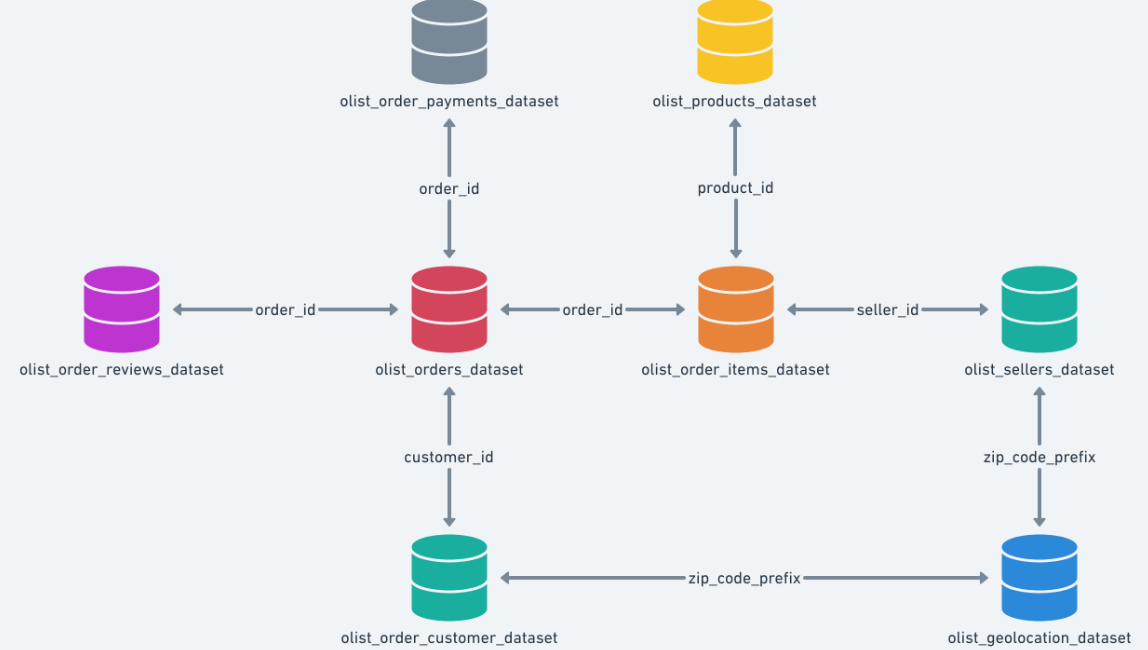

Column names of the tables

olist_customers_dataset : ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

olist_geolocation_dataset : ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

olist_orders_dataset : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

olist_order_items_dataset : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

olist_order_payments_dataset : ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

olist_order_reviews_dataset : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

olist_products_dataset : ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

olist_sellers_dataset : ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

product_category_name_translation : ['product_category_name', 'product_category_name_english']

olist_customers_dataset/df_customers

    Primary key: customer_id
    Foreign key: none

olist_orders_dataset/df_orders

    Primary key: order_id
    Foreign key: customer_id → df_customers

olist_order_items_dataset/df_order_items

    Primary key: order_id + order_item_id (composite)
    Foreign key: order_id → df_orders
    Foreign key: product_id → df_products
    Foreign key: seller_id → df_sellers

olist_order_payments_dataset/df_payments

    Primary key: none
    Foreign key: order_id → df_orders

olist_order_reviews_dataset/df_reviews

    Primary key: none (review_id is NOT an unique identifier)
    (data quality issue: 789 review_ids mapped to multiple order_ids)
    (547 order_ids affected - same issue, different view)
    Foreign key: order_id → df_orders

olist_products_dataset/df_products

    Primary key: product_id
    Foreign key: product_category_name → df_translation

olist_sellers_dataset/df_sellers

    Primary key: seller_id
    Foreign key: none

olist_geolocation_dataset/df_geolocation

    Primary key: none
    Foreign key: none

product_category_name_translation/df_translation

    Primary key: product_category_name
    Foreign key: none

In [92]:
# Orphan Check

In [93]:
# Check for customers and Orders

In [94]:
query = """SELECT COUNT(*) AS orphaned_orders
FROM olist_orders_dataset o 
LEFT JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
WHERE c.customer_id IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_orders
0,0


In [95]:
# Result: 0 orphaned rows
# All customer_ids in the orders exist in the customers table

In [96]:
# Check for Orders and Order_items

In [97]:
query = """SELECT COUNT(*) AS orphaned_order_items
FROM olist_order_items_dataset oi 
LEFT JOIN olist_orders_dataset o 
ON oi.order_id = o.order_id
WHERE o.order_id IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_order_items
0,0


In [98]:
# Result: 0 orphaned rows
# All order_ids in the order_items exist in the orders table

In [99]:
# Check for Orders and Payments

In [100]:
query = """SELECT COUNT(*) AS orphaned_payments
FROM olist_order_payments_dataset p
LEFT JOIN olist_orders_dataset o 
ON p.order_id = o.order_id
WHERE o.order_id IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_payments
0,0


In [101]:
# Result: 0 orphaned rows
# All order_ids in the order_payments exist in the orders table

In [102]:
# Check for Products and Order_items

In [103]:
query = """SELECT COUNT(*) as orphaned_order_items
FROM olist_order_items_dataset oi
LEFT JOIN olist_products_dataset p 
ON oi.product_id = p.product_id
WHERE p.product_id IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_order_items
0,0


In [104]:
# Check for sellers and Order_items

In [105]:
query = """SELECT COUNT(*) as orphaned_order_items
FROM olist_order_items_dataset oi
LEFT JOIN olist_sellers_dataset s
ON oi.seller_id = s.seller_id
WHERE s.seller_id IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_order_items
0,0


In [106]:
# Check between orders and reviews

In [107]:
query = """SELECT COUNT(*) AS orphaned_reviews
FROM olist_order_reviews_dataset r
LEFT JOIN olist_orders_dataset o
ON r.order_id = o.order_id
WHERE o.order_id IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_reviews
0,0


In [108]:
# Result: 0 orphaned records — clean
# Note: separate duplicate mapping issue exists (789 review_ids, 547 order_ids)
# That is a different data quality issue, not an orphan issue

In [109]:
# Check between products and translations 
query = """SELECT COUNT(*) as orphaned_products
FROM olist_products_dataset p
LEFT JOIN product_category_name_translation t
ON p.product_category_name = t.product_category_name
WHERE t.product_category_name IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_products
0,623


In [110]:
# Result: 623 orphaned products
# 623 products have category names with no matching translation
# Known mismatch — 73 categories in products, 71 in translation table
# These products will have NULL english category name when joined

In [111]:
query = """SELECT p.product_category_name, COUNT(*) AS orphaned_products_in_this_category
FROM olist_products_dataset p
LEFT JOIN product_category_name_translation t
ON p.product_category_name = t.product_category_name
WHERE t.product_category_name IS NULL
GROUP BY p.product_category_name
ORDER BY orphaned_products_in_this_category DESC;"""

check = pd.read_sql(query,engine)
check

,product_category_name,orphaned_products_in_this_category
0,NaN,610
1,portateis_cozinha_e_preparadores_de_alimentos,10
2,pc_gamer,3


In [112]:
# Result: 623 orphaned products broken down as:
# - 610 products have NULL category name (found in profiling phase)
# - 13 products belong to 2 categories missing from translation table
# Decision: these will show NULL for english category name when joined

_____________

In [113]:
# Cardinality Check

In [114]:
# Logical Check:
# Customers → Orders: one to one (each customer_id appears once in both tables)
    # BUT customer_unique_id → Orders: one to many (same real customer can place many orders)
# Orders → Order Items: one to many (one order can have multiple products)
# Orders → Payments: one to many (one order can have multiple payment methods)
# Orders → Reviews: expected one to one, actual one to many (547 orders have multiple reviews - data quality issue) 
    # (789 reviews are mapped to multiple orders)
# Order Items → Products: many to one (many order items can reference same product)
# Order Items → Sellers: many to one (many order items can reference same seller)
# Products → Translation: many to one (many products belong to one category, one category has one english translation)
    # 610 products have NULL category name - No translation possible
    # 13 products belongs to 2 categories missing from translation table
    # These will show NULL English category translations when joined

In [115]:
# Confirmations

In [116]:
# Customers → Orders: one to one
# customer_id is unique in both tables and no orphan rows found in orphan check phase
# Customers → Orders: one to one confirmed

In [117]:
# Orders → Order Items: one to many
# Checking many side - max items per order
query = """SELECT MAX(item_count) as max_items
FROM (
    SELECT order_id, COUNT(*) as item_count
    FROM olist_order_items_dataset
    GROUP BY order_id
) AS T;"""
check = pd.read_sql(query, engine)
check
# Orders side - order_id is unique identifier, already confirmed in data understanding phase

,max_items
0,21


In [118]:
# Orders → Order Items: one to many confirmed

In [119]:
# Orders → Order Items: one to many 
# Checking many side - max payments per order
query = """WITH payment_counts AS (
    SELECT order_id, COUNT(*) as payment_count
    FROM olist_order_payments_dataset
    GROUP BY order_id
)
SELECT MAX(payment_count) as max_payments
FROM payment_counts;"""
check = pd.read_sql(query, engine)
check
# Orders side - order_id is unique identifier, already confirmed in data understanding phase

,max_payments
0,29


In [120]:
# Orders → Order Items: one to many confirmed

In [121]:
# Order Items → Products: many to one
# Checking many side - max order items per product
query = """WITH product_counts AS (
    SELECT product_id, COUNT(*) as item_count
    FROM olist_order_items_dataset
    GROUP BY product_id
)
SELECT MAX(item_count) as max_items_per_product
FROM product_counts;"""
check = pd.read_sql(query, engine)
check
# Products side - product_id is unique identifier, already confirmed in data understanding phase

,max_items_per_product
0,527


In [122]:
# Order Items → Products: many to one confirmed

In [123]:
# Orders → Reviews: expected one to one, actual one to many
# Checking many side - max reviews per order
query = """WITH review_counts AS (
    SELECT order_id, COUNT(*) as review_count
    FROM olist_order_reviews_dataset
    GROUP BY order_id
)
SELECT MAX(review_count) as max_reviews
FROM review_counts;"""
check = pd.read_sql(query, engine)
check

# Orders side - order_id is unique identifier, already confirmed in data understanding phase

    # Expected one to one but actual one to many - data quality issue already found in profiling phase
    # 547 orders mapped to multiple reviews, 789 review_ids mapped to multiple orders

,max_reviews
0,3


In [124]:
# Orders → Reviews: expected one to one, actual one to many confirmed

In [125]:
# Order Items → Sellers: many to one
# Checking many side - max order items per seller
query = """WITH seller_counts AS (
    SELECT seller_id, COUNT(*) as item_count
    FROM olist_order_items_dataset
    GROUP BY seller_id
)
SELECT MAX(item_count) as max_items_per_seller
FROM seller_counts;"""
check = pd.read_sql(query, engine)
check
# Sellers side - seller_id is unique identifier, already confirmed in data understanding phase

,max_items_per_seller
0,2033


In [126]:
# Order Items → Sellers: many to one confirmed

In [127]:
# Products → Translation: many to one
# Checking many side - max products per category
query = """WITH category_counts AS (
    SELECT product_category_name, COUNT(*) as product_count
    FROM olist_products_dataset
    WHERE product_category_name IS NOT NULL
    GROUP BY product_category_name
)
SELECT MAX(product_count) as max_products_per_category
FROM category_counts;"""
check = pd.read_sql(query, engine)
check
# Translation side - product_category_name is unique identifier, already confirmed in data understanding phase
    # 610 products have null category name - no translation possible
    # 13 products belong to 2 categories missing from translation table

,max_products_per_category
0,3029


In [128]:
# Products → Translation: many to one confirmed

_______________

In [129]:
# Join Validation - Fan-Out and Data Loss Checks

In [130]:
# order_datset -> central table
# order_items -> secondary hub 

In [131]:
# Fan out and data loss check: Customers -> Orders
query = """
WITH joined AS (
    SELECT c.customer_id, o.order_id
    FROM olist_customers_dataset c
    LEFT JOIN olist_orders_dataset o
    ON c.customer_id = o.customer_id
)
SELECT
    (SELECT COUNT(*) FROM olist_customers_dataset) as original_rows,
    COUNT(*) as joined_rows,
    COUNT(*) FILTER (WHERE joined.order_id IS NULL) as unmatched_rows,
    CASE
        WHEN COUNT(*) > (SELECT COUNT(*) FROM olist_customers_dataset) THEN 'Fan out occurred'
        WHEN COUNT(*) FILTER (WHERE joined.order_id IS NULL) > 0 THEN 'Data loss occurred'
        ELSE 'Join is clean'
    END as status
FROM joined;
"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,status
0,99441,99441,0,Join is clean


In [132]:
# cardinality: one-to-one
# Each Order has exactly one customer_id, no repeats in orders table
# Join Validation: Join is Clean

In [133]:
# Fan out and data loss check: Orders -> Order_Items
query = """
WITH joined AS (
    SELECT o.order_id, oi.order_item_id
    FROM olist_orders_dataset o
    LEFT JOIN olist_order_items_dataset oi
    ON o.order_id = oi.order_id
)
SELECT
    (SELECT COUNT(*) FROM olist_orders_dataset) as original_rows,
    COUNT(*) as joined_rows,
    COUNT(*) FILTER (WHERE joined.order_item_id IS NULL) as unmatched_rows,
    CASE
        WHEN COUNT(*) > (SELECT COUNT(*) FROM olist_orders_dataset) THEN 'Fan out occurred'
        WHEN COUNT(*) FILTER (WHERE joined.order_item_id IS NULL) > 0 THEN 'Data loss occurred'
        ELSE 'Join is clean'
    END as status
FROM joined;
"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,status
0,99441,113425,775,Fan out occurred


In [134]:
# Result: Fan-Out Occured
# Reason: 
# One-to-Many Relationship - one order can have multiple items 
# So, one order row ,multiplies into as many rows as it has items
# This is expected and normal for this relationship

# 775 unmatched orders - orders with no items recorded
# Quick status check below to confirm which statuses these belong to

In [135]:
query = """
WITH joined AS (
    SELECT o.order_id, o.order_status, oi.order_item_id
    FROM olist_orders_dataset o
    LEFT JOIN olist_order_items_dataset oi
    ON o.order_id = oi.order_id
)
SELECT joined.order_status, COUNT(*) as unmatched_orders
FROM joined
WHERE joined.order_item_id IS NULL
GROUP BY joined.order_status
ORDER BY unmatched_orders DESC
"""
check = pd.read_sql(query, engine)
check

,order_status,unmatched_orders
0,unavailable,603
1,canceled,164
2,created,5
3,invoiced,2
4,shipped,1


In [136]:
# Status breakdownn of  the 775 unmatched orders (no items recorded):
# Unavailable: 603, Cancelled: 164, created: 5, invoiced: 2, shipped: 1

In [137]:
# Original ORDERS PER STATUS
# order_status	counts
# delivered	96478
# shipped	1107
# canceled	625
# unavailable	609
# invoiced	314
# processing	301
# created	5
# approved	2

In [138]:
# DATA QUALITY ISSUE - 775 orders have no items in order_items table/dataset
# Ideally, every order should have at least one item regardless of status
# these unmatched orders will be  excluded from the item level analysis

# Delivered orders unaffected - revenue analysis is safe

In [139]:
# Fan-out is expected (1 order → multiple items)
# price and freight_value are item-level; safe for analysis at order-item grain.

In [140]:
# Fan out and data loss check: Orders -> Payments
query = """
WITH joined AS (
    SELECT o.order_id, p.payment_sequential
    FROM olist_orders_dataset o
    LEFT JOIN olist_order_payments_dataset p
    ON o.order_id = p.order_id
)
SELECT
    (SELECT COUNT(*) FROM olist_orders_dataset) as original_rows,
    COUNT(*) as joined_rows,
    COUNT(*) FILTER (WHERE joined.payment_sequential IS NULL) as unmatched_rows,
    CASE
        WHEN COUNT(*) > (SELECT COUNT(*) FROM olist_orders_dataset) THEN 'Fan out occurred'
        WHEN COUNT(*) FILTER (WHERE joined.payment_sequential IS NULL) > 0 THEN 'Data loss occurred'
        ELSE 'Join is clean'
    END as status
FROM joined;
"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,status
0,99441,103887,1,Fan out occurred


In [141]:
# Status: Fan-out occurred — expected, one order can have multiple payment methods
# 1 order has no payment recorded — minor data quality issue
# This order will be excluded from payment level analysis

In [142]:
query = """
WITH joined AS (
    SELECT o.order_id, o.order_status, p.payment_sequential
    FROM olist_orders_dataset o
    LEFT JOIN olist_order_payments_dataset p
    ON o.order_id = p.order_id
)
SELECT order_status, COUNT(*) AS unmatched_orders
FROM joined
WHERE payment_sequential IS NULL
GROUP BY order_status
"""
check = pd.read_sql(query, engine)
check

,order_status,unmatched_orders
0,delivered,1


In [143]:
query = """SELECT o.order_id
FROM olist_orders_dataset o
LEFT JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id
WHERE p.payment_sequential IS NULL
AND o.order_status = 'delivered';"""
check = pd.read_sql(query, engine)
check

,order_id
0,bfbd0f9bdef84302105ad712db648a6c


In [144]:
# 1 unmatched delivered order found — order ID: [bfbd0f9bdef84302105ad712db648a6c]
# Delivered order with no payment recorded
# Serious data quality issue — excluded from payment analysis

In [145]:
# Fan out and data loss check: Orders -> Reviews
query = """
WITH joined AS (
    SELECT o.order_id, r.review_id
    FROM olist_orders_dataset o
    LEFT JOIN olist_order_reviews_dataset r
    ON o.order_id = r.order_id
)
SELECT
    (SELECT COUNT(*) FROM olist_orders_dataset) as original_rows,
    COUNT(*) as joined_rows,
    COUNT(*) FILTER (WHERE review_id IS NULL) as unmatched_rows,
    CASE
        WHEN COUNT(*) > (SELECT COUNT(*) FROM olist_orders_dataset) THEN 'Fan out occurred'
        WHEN COUNT(*) FILTER (WHERE review_id IS NULL) > 0 THEN 'Missing reviews exist' 
        ELSE 'Join is clean'
    END as status
FROM joined;
"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,status
0,99441,99992,768,Fan out occurred


In [146]:
# Status: Fan-out occurred — expected
# Reason: 547 orders have multiple reviews (found in profiling phase)
# 768 orders have no review — normal, not every customer reviews
# When joining reviews, use latest review per order_id based on review_answer_timestamp

In [147]:
# Reviews → Orders: Two related but separate anomalies
# 789 review_ids mapped to multiple order_ids (both found in data profilling or understanding phase)
# 547 order_ids have multiple review_ids
# These two together create many-to-many like behavior, in what should be a one-to-many relationship
# They overlap but are not the same issue
# Decision: use latest review per order_id based on review_answer_timestamp

In [148]:
# Fan out and data loss check: Order_Items -> Sellers
query = """
WITH joined AS (
    SELECT oi.order_id, oi.order_item_id, oi.seller_id, s.seller_id AS seller_match
    FROM olist_order_items_dataset oi
    LEFT JOIN olist_sellers_dataset s
    ON oi.seller_id = s.seller_id
)
SELECT
    (SELECT COUNT(*) FROM olist_order_items_dataset) as original_rows,
    COUNT(*) as joined_rows,
    COUNT(*) FILTER (WHERE seller_match IS NULL) as unmatched_rows,
    CASE
        WHEN COUNT(*) > (SELECT COUNT(*) FROM olist_order_items_dataset) THEN 'Fan out occurred'
        WHEN COUNT(*) FILTER (WHERE seller_match IS NULL) > 0 THEN 'Missing sellers exist'
        ELSE 'Join is clean'
    END as status
FROM joined;
"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,status
0,112650,112650,0,Join is clean


In [149]:
# Status: Join is clean
# Expected result because:
    # No null values in seller_id in order_items table
    # No orphaned seller_ids found in orphan check
    # seller_id is unique identifier in sellers table
# Every order item is linked to a valid seller

In [150]:
# Fan out and data loss check: Order_Items -> Products
query = """
WITH joined AS (
    SELECT oi.order_id, oi.order_item_id, oi.product_id, p.product_id AS product_match
    FROM olist_order_items_dataset oi
    LEFT JOIN olist_products_dataset p
    ON oi.product_id = p.product_id
)
SELECT
    (SELECT COUNT(*) FROM olist_order_items_dataset) as original_rows,
    COUNT(*) as joined_rows,
    COUNT(*) FILTER (WHERE product_match IS NULL) as unmatched_rows,
    CASE
        WHEN COUNT(*) > (SELECT COUNT(*) FROM olist_order_items_dataset) THEN 'Fan out occurred'
        WHEN COUNT(*) FILTER (WHERE product_match IS NULL) > 0 THEN 'Missing products exist'
        ELSE 'Join is clean'
    END as status
FROM joined;
"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,status
0,112650,112650,0,Join is clean


In [151]:
# Result: join is clean
# Expected result because:
    # No NULL values in the product_id in the order_items table
    # No orphaned product_ids found in orphan check
    # product_id is the unique identifier in products table
# Every order item is linked to a valid product

In [152]:
# Fan-out and data loss check: products → translation
query = """
WITH joined AS (
    SELECT 
        p.product_id,
        p.product_category_name,
        c.product_category_name AS category_match
    FROM olist_products_dataset p
    LEFT JOIN product_category_name_translation c
    ON p.product_category_name = c.product_category_name
)
SELECT
    (SELECT COUNT(*) FROM olist_products_dataset) as original_rows,
    COUNT(*) as joined_rows,
    COUNT(*) FILTER (WHERE category_match IS NULL) as unmatched_rows,
    CASE
        WHEN COUNT(*) > (SELECT COUNT(*) FROM olist_products_dataset) THEN 'Fan out occurred'
        WHEN COUNT(*) FILTER (WHERE category_match IS NULL) > 0 THEN 'Orphan categories exist'
        ELSE 'Join is clean'
    END as status
FROM joined;
"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,status
0,32951,32951,623,Orphan categories exist


In [153]:
# Status: Missing translations exist
# 610 products have null category name — found in profiling phase
# 13 products belong to 2 categories not in translation table
# These 623 will show NULL for English category name when joined
# Not a blocker for analysis

In [154]:
# Fan-out and data loss check: translation → products
query = """
WITH joined AS (
    SELECT 
        c.product_category_name,
        p.product_id
    FROM product_category_name_translation c
    LEFT JOIN olist_products_dataset p
    ON p.product_category_name = c.product_category_name
)
SELECT
    (SELECT COUNT(*) FROM product_category_name_translation) as original_rows,
    COUNT(*) as joined_rows,
    COUNT(*) FILTER (WHERE product_id IS NULL) as unmatched_rows,
    CASE
        WHEN COUNT(*) > (SELECT COUNT(*) FROM product_category_name_translation) THEN 'Fan out occurred'
        WHEN COUNT(*) FILTER (WHERE product_id IS NULL) > 0 THEN 'Orphan categories exist (no products mapped)'
        ELSE 'Join is clean'
    END as status
FROM joined;
"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,status
0,71,32328,0,Fan out occurred


In [155]:
# Status: Fan-out occurred — expected
# All 71 translation categories found in products table
# One category maps to many products — normal one to many relationship

___________

Column names of the tables

olist_customers_dataset : ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

olist_geolocation_dataset : ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

olist_orders_dataset : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

olist_order_items_dataset : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

olist_order_payments_dataset : ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

olist_order_reviews_dataset : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

olist_products_dataset : ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

olist_sellers_dataset : ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

product_category_name_translation : ['product_category_name', 'product_category_name_english']

In [156]:
# Analysis Phase

In [157]:
# Clean Revenue (all statuses except unavailable and canceled) # val doubt
# 1 delivered order doesn't have any row in payment_value
query = """WITH cte AS (
SELECT o.order_id, o.customer_id, o.order_status, p.payment_sequential, p.payment_type, p.payment_installments, p.payment_value
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id
)
SELECT SUM(payment_value) 
FROM cte
WHERE order_status NOT IN ('unavailable', 'canceled')"""
clean_revenue = pd.read_sql(query, engine)
clean_revenue

,sum
0,15739137.01


In [158]:
# 15739137.01 -- when LEFT JOIN + NULL condition

In [159]:
# Total clean orders 
# (all statuses except unavailable and canceled, even the delivered order whose payment data is not givem is included)
# order_id - primary key of orders_dataset - no need for distinct
query = """SELECT COUNT(*) clean_orders
FROM olist_orders_dataset
WHERE order_status NOT IN ('unavailable', 'canceled')"""
clean_orders = pd.read_sql(query, engine)
clean_orders

,clean_orders
0,98207


In [160]:
# check from the order_status distribution we found earlier
# Original ORDERS PER STATUS
# order_status	counts
# delivered	96478
# shipped	1107
# canceled	625
# unavailable	609
# invoiced	314
# processing	301
# created	5
# approved	2
query = """SELECT COUNT(*) - 625 - 609 AS clean_orders
FROM olist_orders_dataset"""
clean_orders = pd.read_sql(query, engine)
clean_orders

,clean_orders
0,98207


In [161]:
# Total Failed Orders (orders that are unavailable or canceled)
# Canceled -> canceled by customer, Unavailable -> Canceled by seller (seller couldn't fulfill or uncavailable product)
query = """SELECT COUNT(*) AS failed_orders
FROM olist_orders_dataset
WHERE order_status IN ('unavailable', 'canceled')"""
failed_orders = pd.read_sql(query, engine)
failed_orders

,failed_orders
0,1234


In [162]:
# check from the order_status distribution we found earlier
# canceled	625
# unavailable	609
625 + 609

1234

In [163]:
# Customer Cancellation Rate
# only canceled orders
query = """SELECT 100.0 * COUNT(*) FILTER(WHERE order_status = 'canceled')/ COUNT(*) AS Customer_cancellation_rate 
FROM olist_orders_dataset"""
Customer_cancellation_rate =  pd.read_sql(query, engine)
Customer_cancellation_rate

,customer_cancellation_rate
0,0.628513


In [164]:
# check from the order_status distribution we found earlier
# canceled	625
query = """SELECT 100.0 * 625 / COUNT(*)
FROM olist_orders_dataset"""
Customer_cancellation_rate =  pd.read_sql(query, engine)
Customer_cancellation_rate

,?column?
0,0.628513


In [165]:
# Unavailibity Rate
# only canceled orders
query = """SELECT 100.0 * COUNT(*) FILTER(WHERE order_status = 'unavailable')/ COUNT(*) AS Unavailibilty_rate
FROM olist_orders_dataset"""
Unavailibilty_rate =  pd.read_sql(query, engine)
Unavailibilty_rate

,unavailibilty_rate
0,0.612423


In [166]:
# check from the order_status distribution we found earlier
# unavailable	609
query = """SELECT 100.0 * 609 / COUNT(*)
FROM olist_orders_dataset"""
Customer_cancellation_rate =  pd.read_sql(query, engine)
Customer_cancellation_rate

,?column?
0,0.612423


In [167]:
# Total Active Sellers
# Sellers with atleast 1 sale
query = """SELECT COUNT(DISTINCT seller_id) AS Total_active_sellers
FROM olist_order_items_dataset"""
active_sellers = pd.read_sql(query, engine)
active_sellers

,total_active_sellers
0,3095


In [168]:
# 100 % active sellers as total no. of sellers is also 3095 (found earlier)

In [169]:
# Repeat Customer Rate (Customer-based Reorder Rate)
# customer_id - primary key
query = """WITH cte AS (
SELECT customer_unique_id, COUNT(customer_id) AS order_nos
FROM olist_customers_dataset
GROUP BY customer_unique_id
HAVING COUNT(customer_id) > 1)
SELECT 100.0 * COUNT(*) / (SELECT COUNT(customer_unique_id) FROM olist_customers_dataset)
FROM cte"""
repeat_cust_rate = pd.read_sql(query, engine)
repeat_cust_rate

,?column?
0,3.013847


In [170]:
# Repeat Purchare Rate (Order-based Reorder Rate)
query = """WITH cte AS (
SELECT c.customer_unique_id, c.customer_id, o.order_id, CAST(o.order_purchase_timestamp AS TIMESTAMP) AS order_purchase_timestamp
FROM olist_customers_dataset c
JOIN olist_orders_dataset o
ON c.customer_id = o.customer_id),
cte2 AS(
SELECT customer_unique_id, customer_id, order_id, order_purchase_timestamp,
ROW_NUMBER() OVER(
PARTITION BY customer_unique_id
ORDER BY order_purchase_timestamp) AS order_no
FROM cte)
SELECT 100.0 * COUNT(*) / (SELECT COUNT(*) FROM olist_orders_dataset)
FROM cte2
WHERE order_no > 1"""
repeat_order_rate = pd.read_sql(query, engine)
repeat_order_rate

,?column?
0,3.363804


In [412]:
# Late deliveries rate 
# 24 Null date - delivered orders, 1373 date logic violations - delivered orders
# excluding them from this analysis, from both numerator and denominator
query = """WITH valid_delivered AS (
SELECT order_id,
        order_status,
        CAST(order_purchase_timestamp AS TIMESTAMP) AS order_purchase_timestamp,
        CAST(order_approved_at AS TIMESTAMP) AS order_approved_at,
        CAST(order_delivered_carrier_date AS TIMESTAMP) AS order_delivered_carrier_date,
        CAST(order_delivered_customer_date AS TIMESTAMP) AS order_delivered_customer_date,
        CAST(order_estimated_delivery_date AS TIMESTAMP) AS order_estimated_delivery_date
FROM olist_orders_dataset
WHERE order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL
AND order_estimated_delivery_date IS NOT NULL
)
SELECT 100.0 * COUNT(*) FILTER (WHERE order_estimated_delivery_date < order_delivered_customer_date)/ 
COUNT(*) AS Late_deliveries_rate
FROM valid_delivered"""
late_del_rate = pd.read_sql(query, engine)
late_del_rate

,late_deliveries_rate
0,8.112367


In [172]:
# Late delivery rate: ~8%
# Based on valid delivered orders only
# Excludes 24 null date rows and 1,373 date logic violations
# from both numerator and denominator

In [173]:
# Review Rates
# classifying review scores:
# 1-2 -> Negative
# 3 -> Neutral
# 4-5 -> Positive

In [174]:
# Positive Review Rate
# Many order_ids have multiple review_ids
query = """WITH latest_reviews AS (
SELECT *,
ROW_NUMBER() OVER(
PARTITION BY order_id ORDER BY review_answer_timestamp DESC
) AS review_no
FROM olist_order_reviews_dataset)
SELECT COUNT(*) FILTER (WHERE review_score >= 4) * 100.0 / COUNT(*) AS positive_review_rate
FROM latest_reviews
WHERE review_no = 1"""
p_review_rate = pd.read_sql(query, engine)
p_review_rate

,positive_review_rate
0,77.068702


In [175]:
# Negative Review Rate
# Many order_ids have multiple review_ids
query = """WITH latest_reviews AS (
SELECT *,
ROW_NUMBER() OVER(
PARTITION BY order_id ORDER BY review_answer_timestamp DESC
) AS review_no
FROM olist_order_reviews_dataset)
SELECT COUNT(*) FILTER (WHERE review_score <= 2) * 100.0 / COUNT(*) AS negative_review_rate
FROM latest_reviews
WHERE review_no = 1"""
n_review_rate = pd.read_sql(query, engine)
n_review_rate

,negative_review_rate
0,14.688922


In [176]:
# left fro now
# Revenue Per Order = Clean Revenue (include its revenue as 0) / Total Clean Orders (include that 1 delivered order with no payment value)

In [177]:
# Gross Revenue
query = """SELECT SUM(p.payment_value)::FLOAT
FROM olist_orders_dataset o
INNER JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id;"""
gross_rev = pd.read_sql(query, engine)
gross_rev

,sum
0,1.600887e+07


In [178]:
# Revenue Gap
# 1 delivered order doesn't have any row in payment_value
query = """WITH cte AS (
SELECT o.order_id, o.customer_id, o.order_status, p.payment_sequential, p.payment_type, p.payment_installments, p.payment_value
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id
)
SELECT 
SUM(payment_value)::FLOAT AS Gross_Revenue, 
SUM(payment_value) FILTER (WHERE order_status NOT IN ('unavailable', 'canceled'))::FLOAT AS Clean_Revenue,
SUM(payment_value) - SUM(payment_value) FILTER (WHERE order_status NOT IN ('unavailable', 'canceled'))::FLOAT AS Revenue_Gap
FROM cte"""
revenue_gap = pd.read_sql(query, engine)
revenue_gap

,gross_revenue,clean_revenue,revenue_gap
0,1.600887e+07,1.573914e+07,269735.11


__MAJOR__KPI__COMPLETE__

__ANALYSIS__OF__TRENDS__START__

Column names of the tables

olist_customers_dataset : ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

olist_geolocation_dataset : ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

olist_orders_dataset : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

olist_order_items_dataset : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

olist_order_payments_dataset : ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

olist_order_reviews_dataset : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

olist_products_dataset : ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

olist_sellers_dataset : ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

product_category_name_translation : ['product_category_name', 'product_category_name_english']

In [179]:
# Monthly order volume trend (all statuses)
# order_purchase_timestamp --> text(initially)
query = """SELECT TO_CHAR(order_purchase_timestamp::TIMESTAMP, 'fmMon-YYYY') AS Month_Year,
COUNT(order_id) AS No_of_Orders
FROM olist_orders_dataset
GROUP BY TO_CHAR(order_purchase_timestamp::TIMESTAMP, 'YYYY-MM'), 
TO_CHAR(order_purchase_timestamp::TIMESTAMP, 'fmMon-YYYY')
ORDER BY TO_CHAR(order_purchase_timestamp::TIMESTAMP, 'YYYY-MM')"""
check = pd.read_sql(query, engine)
check

,month_year,no_of_orders
0,Sep-2016,4
1,Oct-2016,324
2,Dec-2016,1
3,Jan-2017,800
4,Feb-2017,1780
5,Mar-2017,2682
6,Apr-2017,2404
7,May-2017,3700
8,Jun-2017,3245
9,Jul-2017,4026


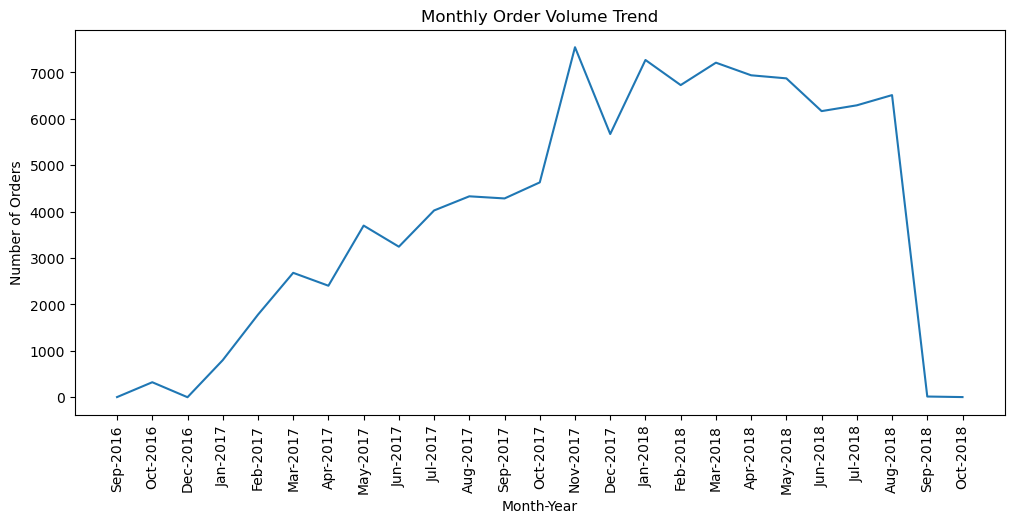

In [180]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(check['month_year'], check['no_of_orders'])

plt.xticks(rotation=90)
plt.xlabel("Month-Year")
plt.ylabel("Number of Orders")
plt.title("Monthly Order Volume Trend")

plt.show()

In [181]:
# Sep 2016 and Oct 2018 - not real demand drops - only partial monthly data available
# “Initial and final months show lower values due to partial data availability and are not considered for trend interpretation.”

In [182]:
# Monthly clean revenue trend
query = """SELECT 
    TO_CHAR(o.order_purchase_timestamp::TIMESTAMP, 'fmMon-YYYY') AS month_year,
    SUM(p.payment_value) AS clean_revenue
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p
    ON o.order_id = p.order_id
WHERE o.order_status NOT IN ('canceled', 'unavailable')
GROUP BY TO_CHAR(order_purchase_timestamp::TIMESTAMP, 'YYYY-MM'), 
TO_CHAR(order_purchase_timestamp::TIMESTAMP, 'fmMon-YYYY')
ORDER BY TO_CHAR(order_purchase_timestamp::TIMESTAMP, 'YYYY-MM');"""
check = pd.read_sql(query, engine)
check

,month_year,clean_revenue
0,Sep-2016,136.23
1,Oct-2016,51657.53
2,Dec-2016,19.62
3,Jan-2017,137006.76
4,Feb-2017,283621.94
5,Mar-2017,425656.40
6,Apr-2017,405988.38
7,May-2017,582926.16
8,Jun-2017,499827.47
9,Jul-2017,578858.58


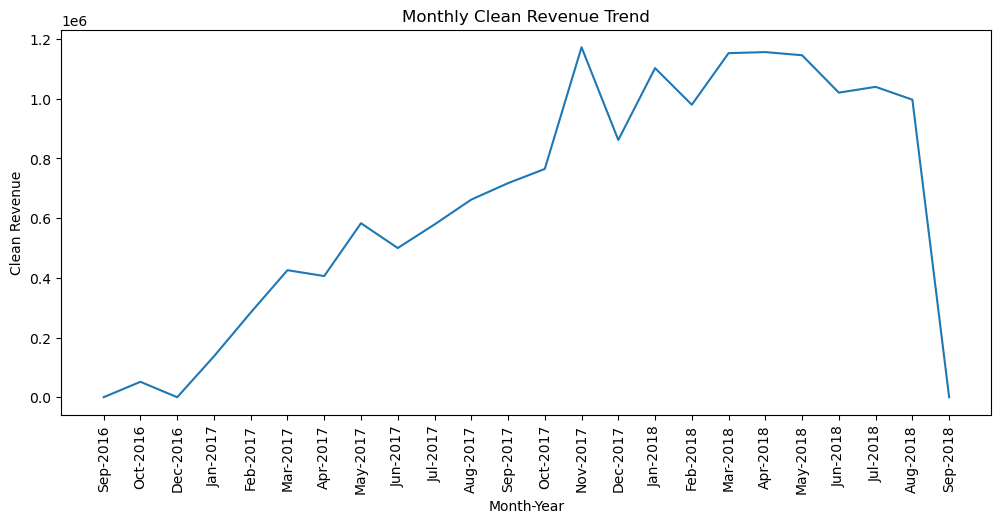

In [183]:
plt.figure(figsize=(12,5))
plt.plot(check['month_year'], check['clean_revenue'])

plt.xticks(rotation=90)
plt.xlabel("Month-Year")
plt.ylabel("Clean Revenue")
plt.title("Monthly Clean Revenue Trend")

plt.show()

In [184]:
# 1 delivered order don't have any payment rows - so, its excluded from this clean_revenue monthly trend

In [185]:
# Revenue by state
query = """WITH cte AS (SELECT o.order_id, o.customer_id, o.order_status, p.payment_sequential, p.payment_installments, p.payment_value
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id),
final AS (SELECT cte.order_id, cte.customer_id, order_status, payment_sequential, payment_value, customer_state
FROM cte 
JOIN olist_customers_dataset c
ON cte.customer_id = c.customer_id)
SELECT customer_state, 
SUM(payment_value) FILTER (WHERE order_status NOT IN ('canceled', 'unavailable')) AS clean_revenue_per_state,
SUM(payment_value) AS gross_revenue_per_state, 
SUM(payment_value) - SUM(payment_value) FILTER (WHERE order_status NOT IN ('canceled', 'unavailable')) AS revenue_gap_per_state
FROM final
GROUP BY customer_state
ORDER BY clean_revenue_per_state DESC"""
check = pd.read_sql(query, engine)
check

,customer_state,clean_revenue_per_state,gross_revenue_per_state,revenue_gap_per_state
0,SP,5878935.99,5998226.96,119290.97
1,RJ,2115994.28,2144379.69,28385.41
2,MG,1843460.37,1872257.26,28796.89
3,RS,877803.80,890898.54,13094.74
4,PR,794653.20,811156.38,16503.18
5,SC,608180.51,623086.43,14905.92
6,BA,607041.45,616645.82,9604.37
7,DF,351487.63,355141.08,3653.45
8,GO,340626.24,350092.31,9466.07
9,ES,323105.75,325967.55,2861.80


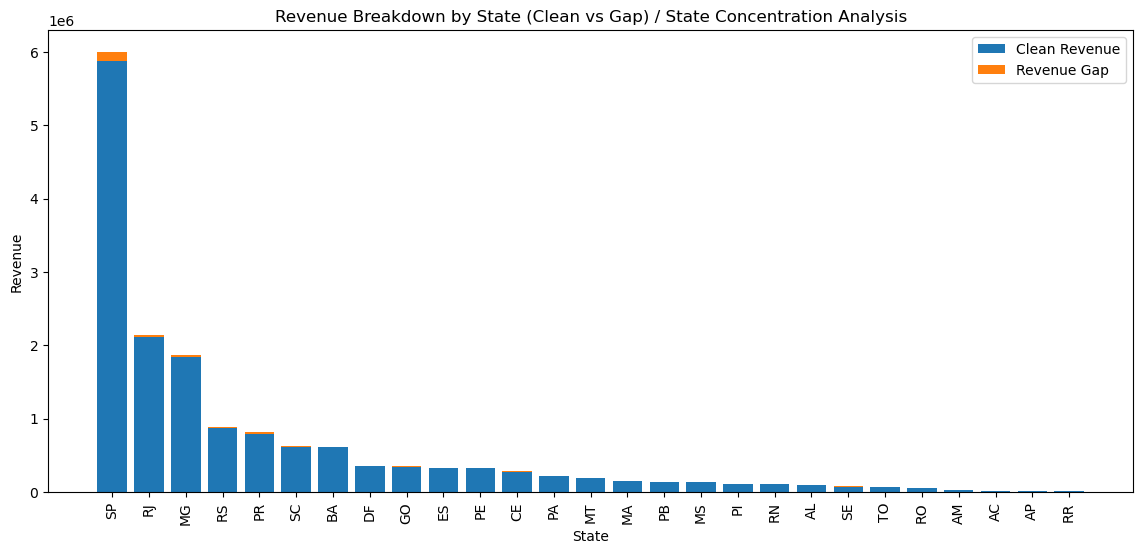

In [186]:
states = check["customer_state"]
clean = check["clean_revenue_per_state"]
gap = check["revenue_gap_per_state"]

plt.figure(figsize=(14,6))

# bottom bar
plt.bar(states, clean, label="Clean Revenue")

# stacked part
plt.bar(states, gap, bottom=clean, label="Revenue Gap")

plt.xlabel("State")
plt.ylabel("Revenue")
plt.title("Revenue Breakdown by State (Clean vs Gap) / State Concentration Analysis")
plt.xticks(rotation=90)
plt.legend()

plt.show()

In [187]:
# Order status breakdown
query = """SELECT 
    order_status,
    COUNT(order_id) AS order_count,
    100.0 * COUNT(order_id) / SUM(COUNT(order_id)) OVER () AS order_percentage
FROM olist_orders_dataset
GROUP BY order_status
ORDER BY order_count DESC;"""
check = pd.read_sql(query, engine)
check

,order_status,order_count,order_percentage
0,delivered,96478,97.020344
1,shipped,1107,1.113223
2,canceled,625,0.628513
3,unavailable,609,0.612423
4,invoiced,314,0.315765
5,processing,301,0.302692
6,created,5,0.005028
7,approved,2,0.002011


In [188]:
# Orders by day of week
query = """SELECT EXTRACT(DOW FROM order_purchase_timestamp::TIMESTAMP)::INT,
TO_CHAR(order_purchase_timestamp::TIMESTAMP, 'fmDay') AS day_of_week,
COUNT(order_id) FILTER (WHERE order_status NOT IN ('canceled', 'unavailable')) AS clean_orders,
COUNT(order_id) FILTER (WHERE order_status IN ('canceled', 'unavailable')) AS failed_orders
FROM olist_orders_dataset
GROUP BY EXTRACT(DOW FROM order_purchase_timestamp::TIMESTAMP),
TO_CHAR(order_purchase_timestamp::TIMESTAMP, 'fmDay')
ORDER BY EXTRACT(DOW FROM order_purchase_timestamp::TIMESTAMP)"""
check = pd.read_sql(query, engine)
check

,extract,day_of_week,clean_orders,failed_orders
0,0,Sunday,11831,129
1,1,Monday,15979,217
2,2,Tuesday,15760,203
3,3,Wednesday,15353,199
4,4,Thursday,14571,190
5,5,Friday,13949,173
6,6,Saturday,10764,123


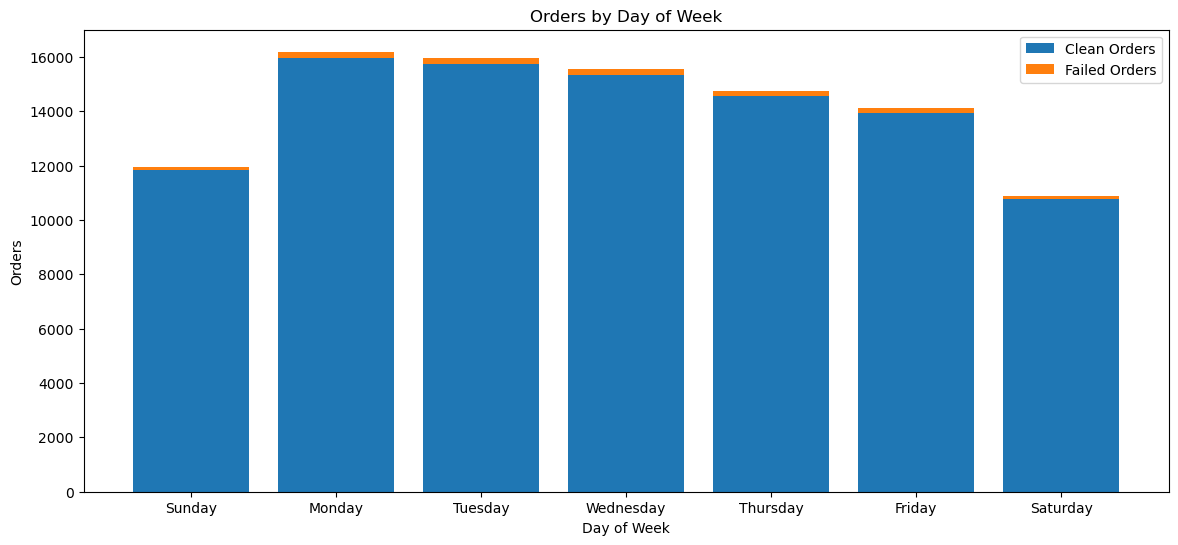

In [189]:
Days = check["day_of_week"]
clean = check["clean_orders"]
failed = check["failed_orders"]

plt.figure(figsize=(14,6))

# bottom bar
plt.bar(Days, clean, label="Clean Orders")

# stacked part
plt.bar(Days, failed, bottom=clean, label="Failed Orders")

plt.xlabel("Day of Week")
plt.ylabel("Orders")
plt.title("Orders by Day of Week")

plt.legend()

plt.show()

In [190]:
# Purchase time (hour) vs orders
# Purchase time by weekday

In [397]:
# Revenue by quarter
query = """SELECT TO_CHAR(DATE_TRUNC('quarter', order_purchase_timestamp::TIMESTAMP),'YYYY-"Q"Q') AS quarter,
SUM(payment_value) AS gross_revenue, 
SUM(payment_value) FILTER (WHERE order_status NOT IN ('canceled', 'unavailable')) AS clean_revenue,
SUM(payment_value) - SUM(payment_value) FILTER (WHERE order_status NOT IN ('canceled', 'unavailable')) AS revenue_gap
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id
GROUP BY DATE_TRUNC('quarter', order_purchase_timestamp::TIMESTAMP)
ORDER BY DATE_TRUNC('quarter', order_purchase_timestamp::TIMESTAMP)"""
check = pd.read_sql(query, engine)
check

,quarter,gross_revenue,clean_revenue,revenue_gap
0,2016-Q3,252.24,136.23,116.01
1,2016-Q4,59110.10,51677.15,7432.95
2,2017-Q1,880259.65,846285.10,33974.55
3,2017-Q2,1521983.23,1488742.01,33241.22
4,2017-Q3,1994541.69,1958125.57,36416.12
5,2017-Q4,2852962.16,2799338.97,53623.19
6,2018-Q1,3267119.64,3235342.38,31777.26
7,2018-Q2,3338648.13,3322546.83,16101.30
8,2018-Q3,2093405.61,2036942.77,56462.84
9,2018-Q4,589.67,NaN,NaN


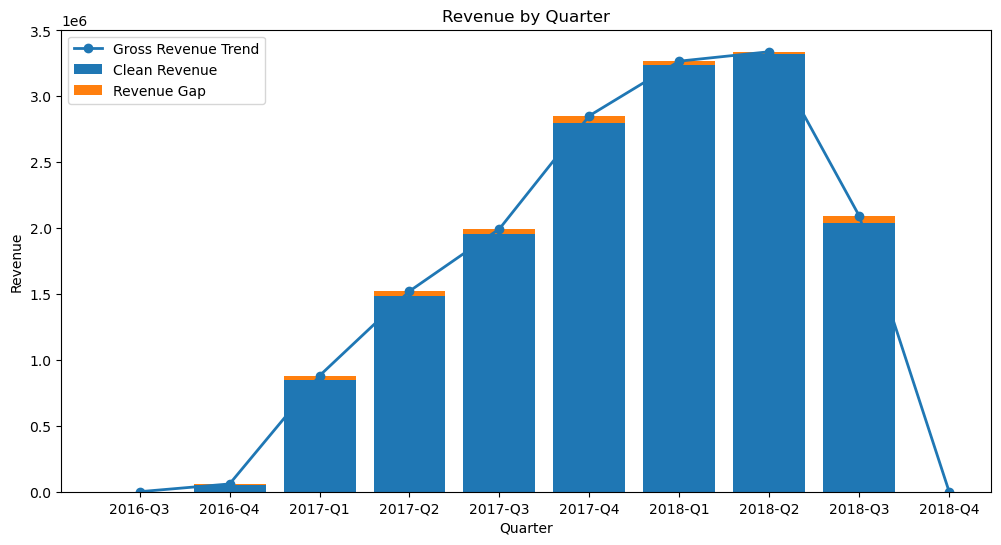

In [398]:

quarters = check["quarter"]
clean = check["clean_revenue"]
gap = check["revenue_gap"]

plt.figure(figsize=(12,6))

# Stacked bars
plt.bar(quarters, clean, label="Clean Revenue")
plt.bar(quarters, gap, bottom=clean, label="Revenue Gap")

# Trend line (Gross Revenue)
plt.plot(
    quarters,
    check["gross_revenue"],
    marker="o",
    linewidth=2,
    label="Gross Revenue Trend"
)

plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.title("Revenue by Quarter")
plt.legend()

plt.show()

In [193]:
# 1 delivered order -> no payment row
# 2016-Q3 and 2018-Q4 -> partial quarters

In [194]:
# Order Item Occurences per Category
query = """WITH cte1 AS (SELECT order_id, order_item_id, oi.product_id, 
COALESCE(product_category_name, 'Other') AS product_category_name
FROM olist_order_items_dataset oi
JOIN olist_products_dataset p
ON oi.product_id = p.product_id),
cte2 AS (SELECT o.order_id, o.order_status, order_item_id, product_id, product_category_name
FROM olist_orders_dataset o
JOIN cte1
ON o.order_id = cte1.order_id)
SELECT product_category_name, 
COUNT(*) FILTER (WHERE order_status NOT IN ('canceled', 'unavailable')) AS clean_orders,
COUNT(*) FILTER (WHERE order_status IN ('canceled', 'unavailable')) AS fail_orders
FROM cte2
GROUP BY product_category_name
ORDER BY COUNT(*) FILTER (WHERE order_status NOT IN ('canceled', 'unavailable')) DESC;"""
check = pd.read_sql(query, engine)
check

,product_category_name,clean_orders,fail_orders
0,cama_mesa_banho,11097,18
1,beleza_saude,9634,36
2,esporte_lazer,8590,51
3,moveis_decoracao,8298,36
4,informatica_acessorios,7781,46
...,...,...,...
69,cds_dvds_musicais,14,0
70,portateis_cozinha_e_preparadores_de_alimentos,14,1
71,fashion_roupa_infanto_juvenil,8,0
72,pc_gamer,8,1


In [195]:
# no orphan rows in any on the joins - in validation phase
# Other --> original category name: NULL

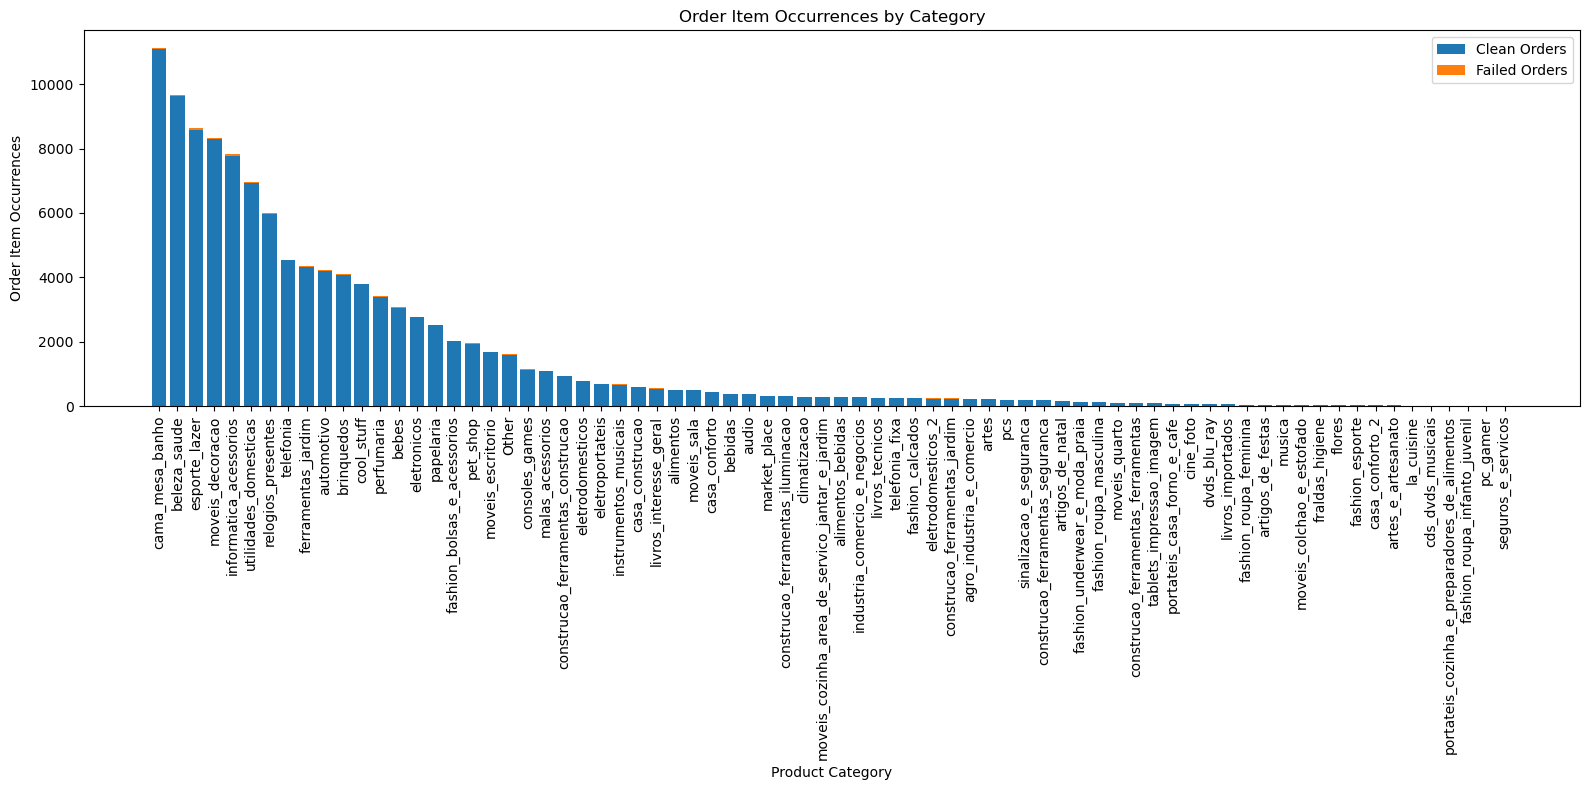

In [196]:
categories = check["product_category_name"]
clean = check["clean_orders"]
failed = check["fail_orders"]

plt.figure(figsize=(16,8))

# Clean occurrences
plt.bar(categories, clean, label="Clean Orders")

# Failed occurrences stacked on top
plt.bar(categories, failed, bottom=clean, label="Failed Orders")

plt.xlabel("Product Category")
plt.ylabel("Order Item Occurrences")
plt.title("Order Item Occurrences by Category")
plt.xticks(rotation=90)
plt.legend()

plt.tight_layout()
plt.show()

In [419]:
# Cancellation Rate by Category 
# measures the percentage of orders containing products from a category that were ultimately canceled.
query = """WITH cte AS (SELECT o.order_id, o.order_status, oi.order_item_id, oi.product_id, 
COALESCE(p.product_category_name, 'Other') AS product_category_name
FROM olist_orders_dataset o
JOIN olist_order_items_dataset oi
ON o.order_id = oi.order_id
JOIN olist_products_dataset p
ON oi.product_id = p.product_id)
SELECT product_category_name,
COUNT(DISTINCT order_id) FILTER (WHERE order_status = 'canceled') AS canceled_orders,
COUNT(DISTINCT order_id) AS total_orders,
100.0 * COUNT(DISTINCT order_id) FILTER (WHERE order_status = 'canceled') / COUNT(DISTINCT order_id) AS cancellation_rate
FROM cte
GROUP BY product_category_name
ORDER BY cancellation_rate DESC;"""
check = pd.read_sql(query, engine)
check

,product_category_name,canceled_orders,total_orders,cancellation_rate
0,pc_gamer,1,8,12.500000
1,portateis_cozinha_e_preparadores_de_alimentos,1,14,7.142857
2,fraldas_higiene,1,27,3.703704
3,dvds_blu_ray,2,59,3.389831
4,telefonia_fixa,3,217,1.382488
...,...,...,...,...
69,pcs,0,181,0.000000
70,portateis_casa_forno_e_cafe,0,75,0.000000
71,seguros_e_servicos,0,2,0.000000
72,sinalizacao_e_seguranca,0,140,0.000000


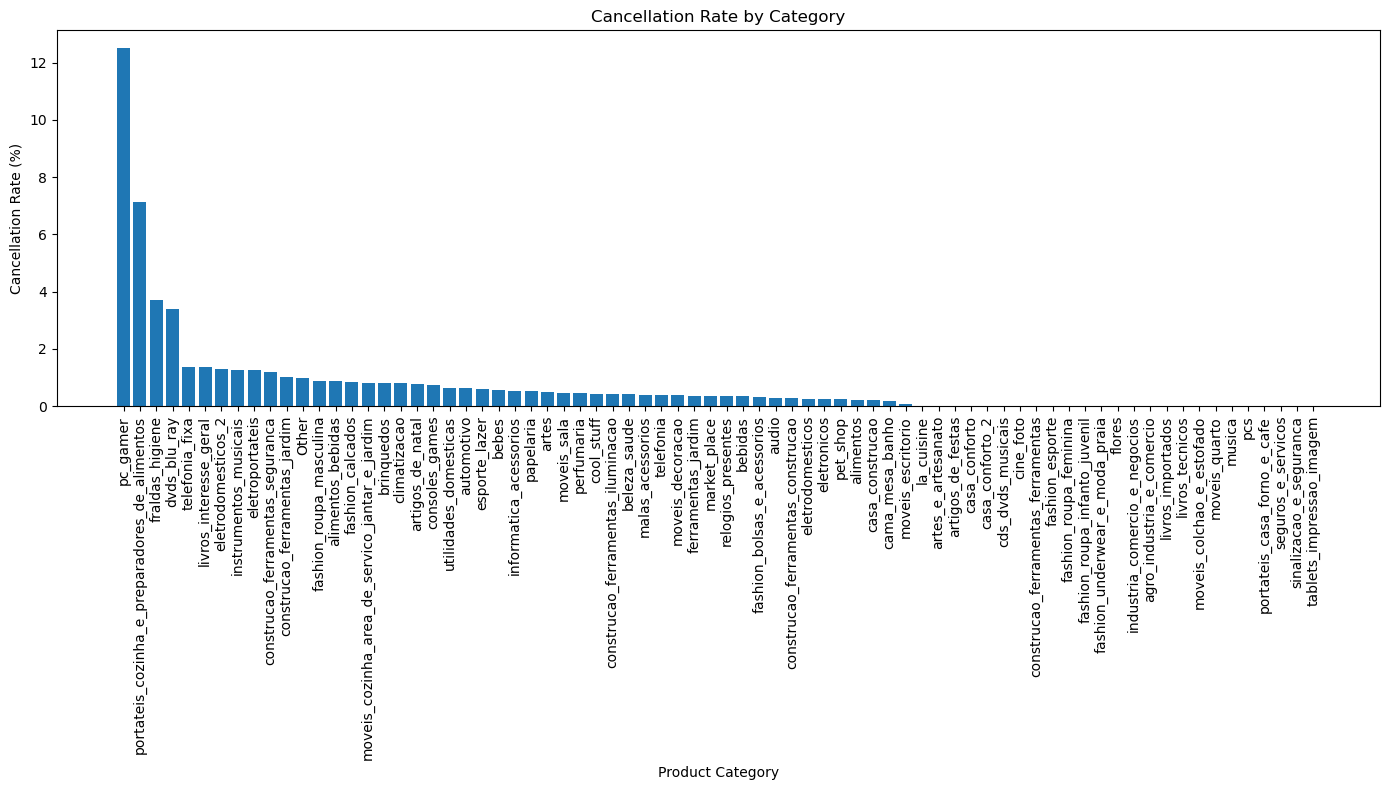

In [420]:
plt.figure(figsize=(14,8))

plt.bar(
    check["product_category_name"],
    check["cancellation_rate"]
)

plt.xlabel("Product Category")
plt.ylabel("Cancellation Rate (%)")
plt.title("Cancellation Rate by Category")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [201]:
# Customer concentration by order frequency

In [404]:
# Customer concentration by order frequency
query = """SELECT customer_unique_id, COUNT(customer_id) AS orders
FROM olist_customers_dataset
GROUP BY customer_unique_id
ORDER BY orders DESC;"""
check = pd.read_sql(query, engine)
check

,customer_unique_id,orders
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,1b6c7548a2a1f9037c1fd3ddfed95f33,7
3,6469f99c1f9dfae7733b25662e7f1782,7
4,ca77025e7201e3b30c44b472ff346268,7
...,...,...
96091,041eaf07c71e1d56b489dff63a270e6a,1
96092,041eb6136ede40c0bd0f31372d7f481e,1
96093,041ecd93f392ac99f53809f2fc47c7fb,1
96094,041fb341560d3bb7036cfab81cfbf063,1


In [405]:
check["orders"].value_counts().sort_index()

orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

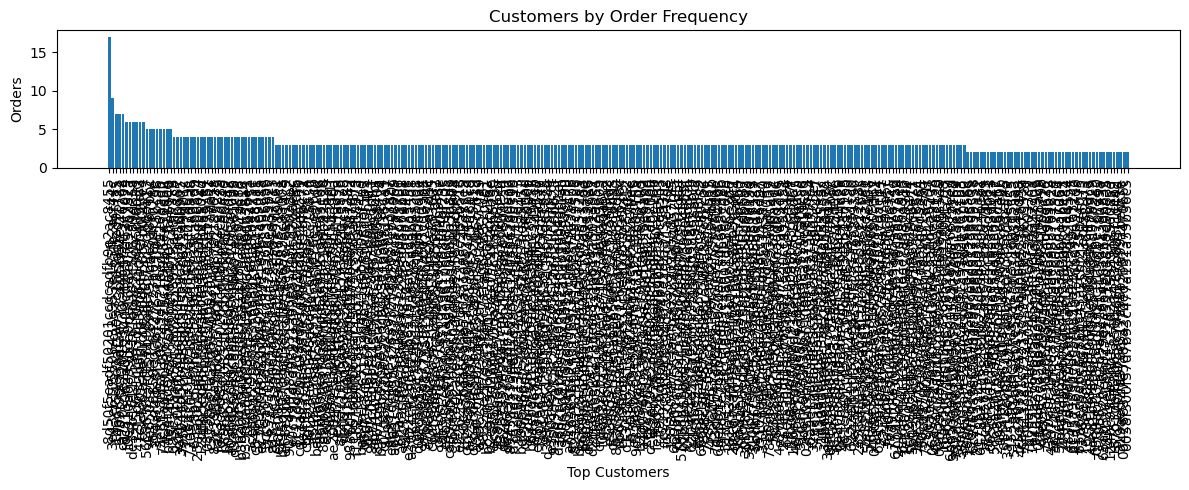

In [406]:
top = check.head(300)

plt.figure(figsize=(12,5))

plt.bar(top["customer_unique_id"], top["orders"])

plt.xlabel("Top Customers")
plt.ylabel("Orders")
plt.title("Customers by Order Frequency")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [410]:
# Seller concentration (order-level)
query = """SELECT oi.seller_id,
COUNT(DISTINCT oi.order_id) FILTER (WHERE o.order_status NOT IN ('canceled', 'unavailable')) AS successful_orders,
COUNT(DISTINCT oi.order_id) FILTER (WHERE o.order_status IN ('canceled', 'unavailable')) AS failed_orders
FROM olist_order_items_dataset oi
JOIN olist_orders_dataset o
ON oi.order_id = o.order_id
GROUP BY oi.seller_id;"""
check = pd.read_sql(query, engine)
check

,seller_id,successful_orders,failed_orders
0,0015a82c2db000af6aaaf3ae2ecb0532,3,0
1,001cca7ae9ae17fb1caed9dfb1094831,200,0
2,001e6ad469a905060d959994f1b41e4f,0,1
3,002100f778ceb8431b7a1020ff7ab48f,51,0
4,003554e2dce176b5555353e4f3555ac8,1,0
...,...,...,...
3090,ffcfefa19b08742c5d315f2791395ee5,0,1
3091,ffdd9f82b9a447f6f8d4b91554cc7dd3,18,0
3092,ffeee66ac5d5a62fe688b9d26f83f534,14,0
3093,fffd5413c0700ac820c7069d66d98c89,59,1


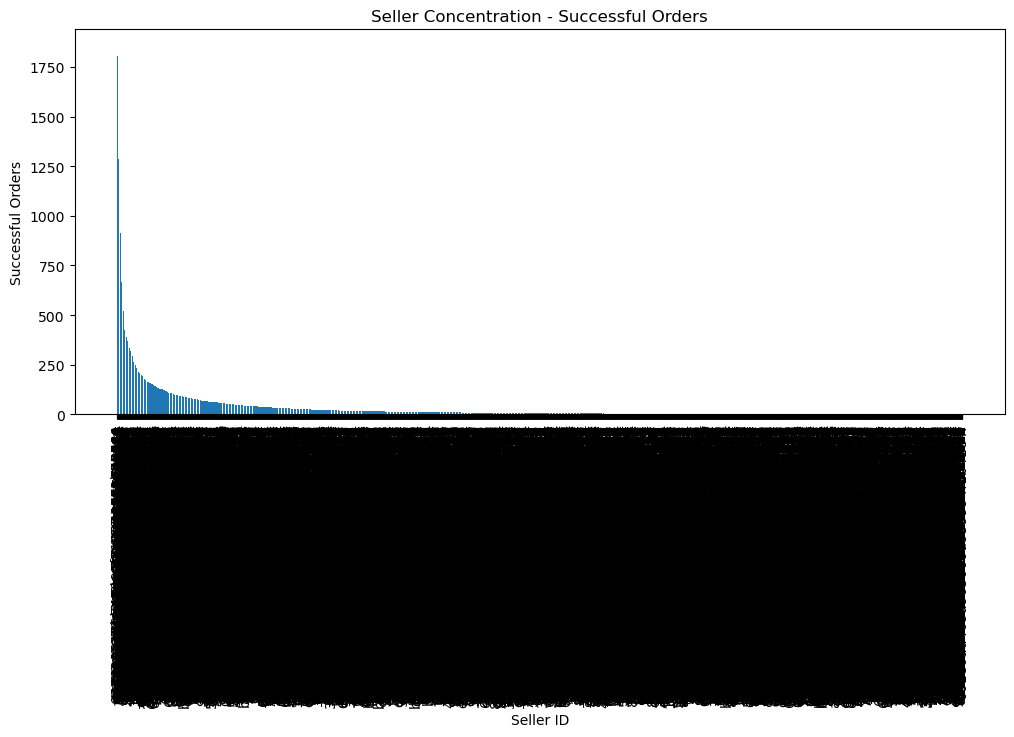

In [411]:
top_success = check.sort_values("successful_orders", ascending=False).head(3095)

plt.figure(figsize=(12,5))
plt.bar(top_success["seller_id"], top_success["successful_orders"])
plt.xticks(rotation=90)
plt.title("Seller Concentration - Successful Orders")
plt.xlabel("Seller ID")
plt.ylabel("Successful Orders")
plt.show()

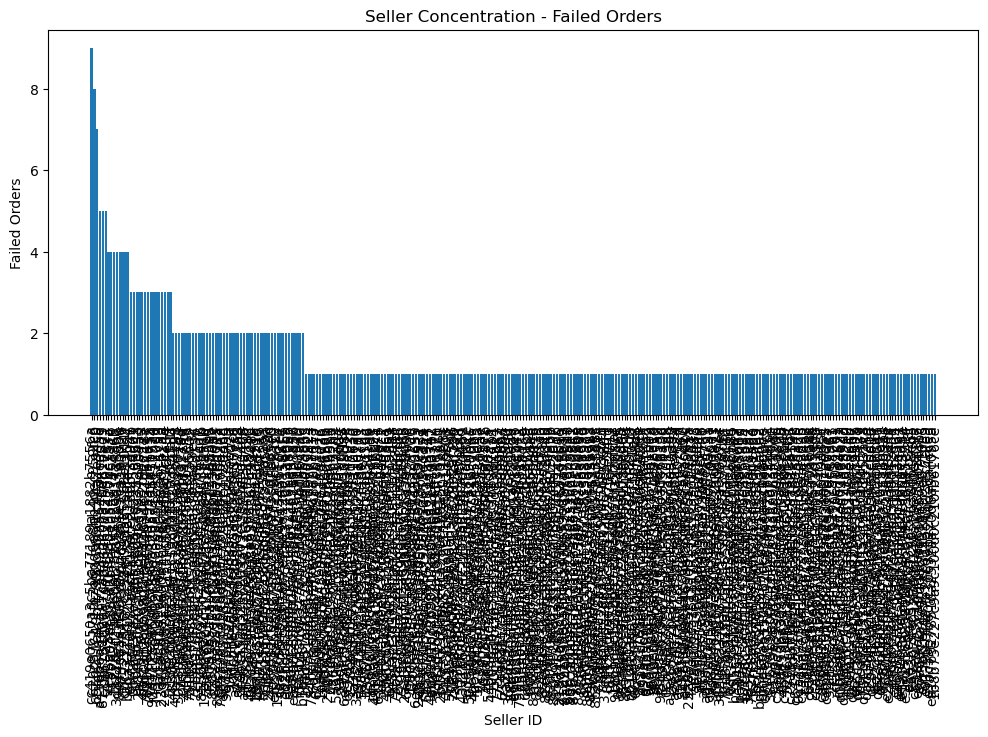

In [219]:
top_failed = check.sort_values("failed_orders", ascending=False).head(300)

plt.figure(figsize=(12,5))
plt.bar(top_failed["seller_id"], top_failed["failed_orders"])
plt.xticks(rotation=90)
plt.title("Seller Concentration - Failed Orders")
plt.xlabel("Seller ID")
plt.ylabel("Failed Orders")
plt.show()

In [431]:
# Seller Concentration (items-level)
query = """SELECT oi.seller_id,
COUNT(*) FILTER (WHERE o.order_status NOT IN ('canceled', 'unavailable')) AS successful_items,
COUNT(*) FILTER (WHERE o.order_status IN ('canceled', 'unavailable')) AS failed_items,
SUM(oi.price) FILTER (WHERE o.order_status NOT IN ('canceled', 'unavailable')) AS clean_revenue
FROM olist_order_items_dataset oi
JOIN olist_orders_dataset o
ON oi.order_id = o.order_id
GROUP BY oi.seller_id;"""
check = pd.read_sql(query, engine)
check

,seller_id,successful_items,failed_items,clean_revenue
0,a61cc04793308395a840807104365121,1,0,14.63
1,6d2f2e3b539480db1e0842b3a4e32e6e,6,0,305.96
2,c53bcd3be457a342a97e39e5a9f0be22,5,0,509.50
3,9591fc341b1bfb7ef561e2968ec6e011,1,0,79.90
4,f9ec7093df3a7b346b7bcf7864069ca3,9,0,519.20
...,...,...,...,...
3090,b2eecf5ea250510da76590ca79d60e5d,11,0,1060.00
3091,eae9af4811c294c56795d70e715b7337,1,0,15.90
3092,1c83418358f249c9d6affa52d579db0e,1,0,24.90
3093,845e8036c3f7bf62099352f5ed910240,24,0,1584.60


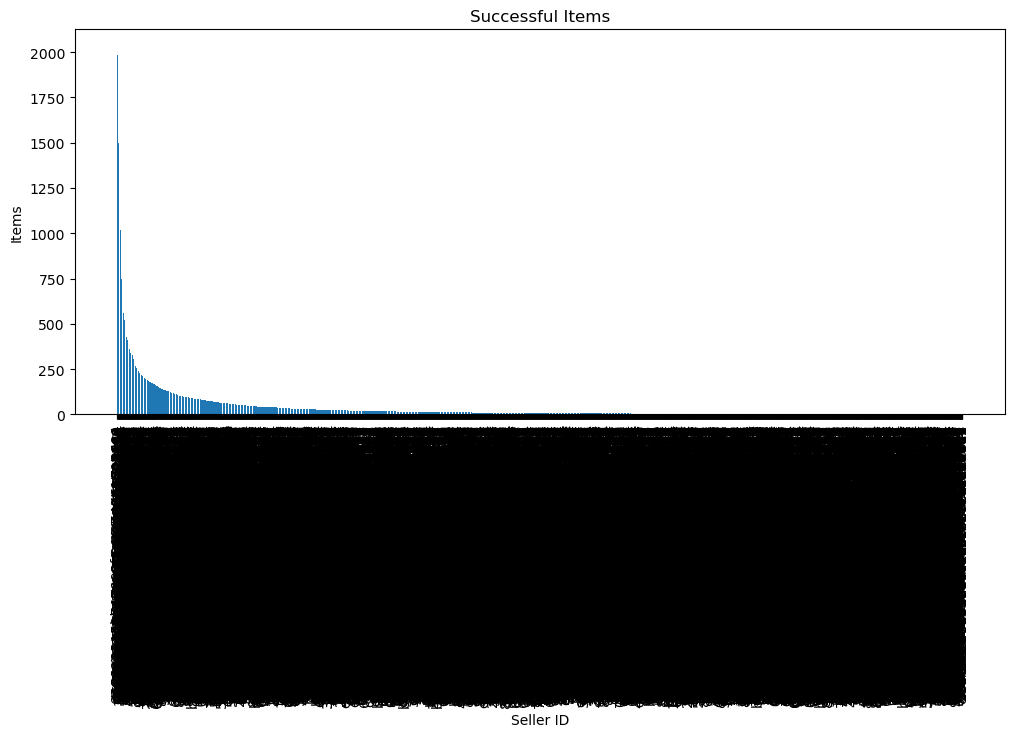

In [432]:
top_success = check.sort_values("successful_items", ascending=False).head(3095)

plt.figure(figsize=(12,5))
plt.bar(top_success["seller_id"], top_success["successful_items"])
plt.xticks(rotation=90)
plt.title("Successful Items")
plt.ylabel("Items")
plt.xlabel("Seller ID")
plt.show()

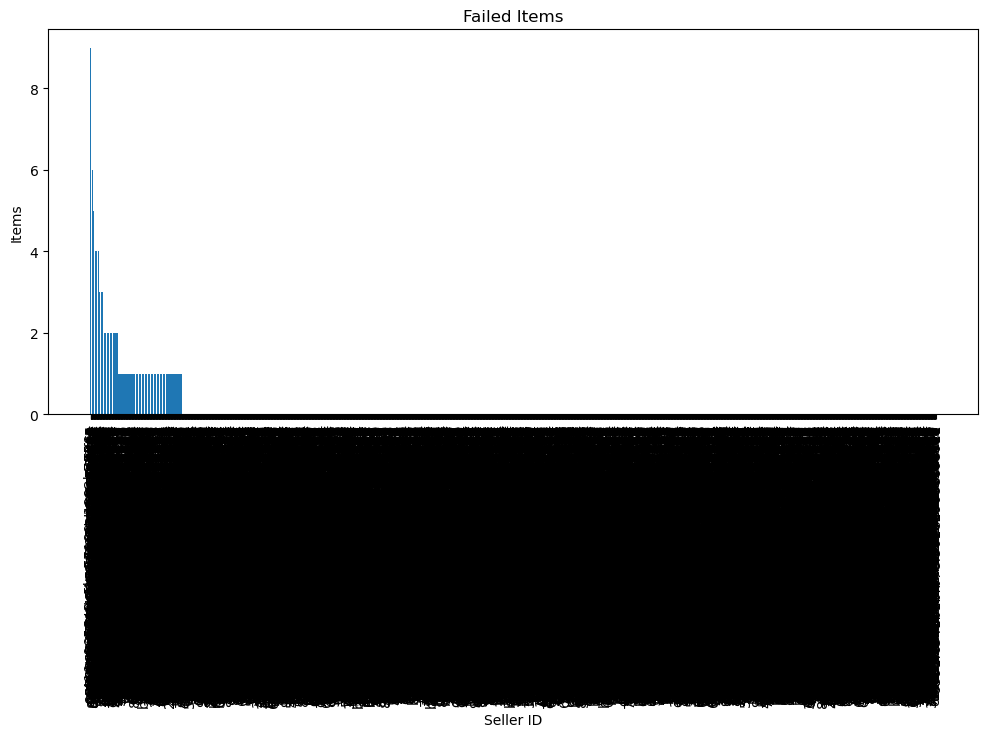

In [433]:
top_failed = check.sort_values("failed_items", ascending=False).head(3095)

plt.figure(figsize=(12,5))
plt.bar(top_failed["seller_id"], top_failed["failed_items"])
plt.xticks(rotation=90)
plt.title("Failed Items")
plt.ylabel("Items")
plt.xlabel("Seller ID")
plt.show()

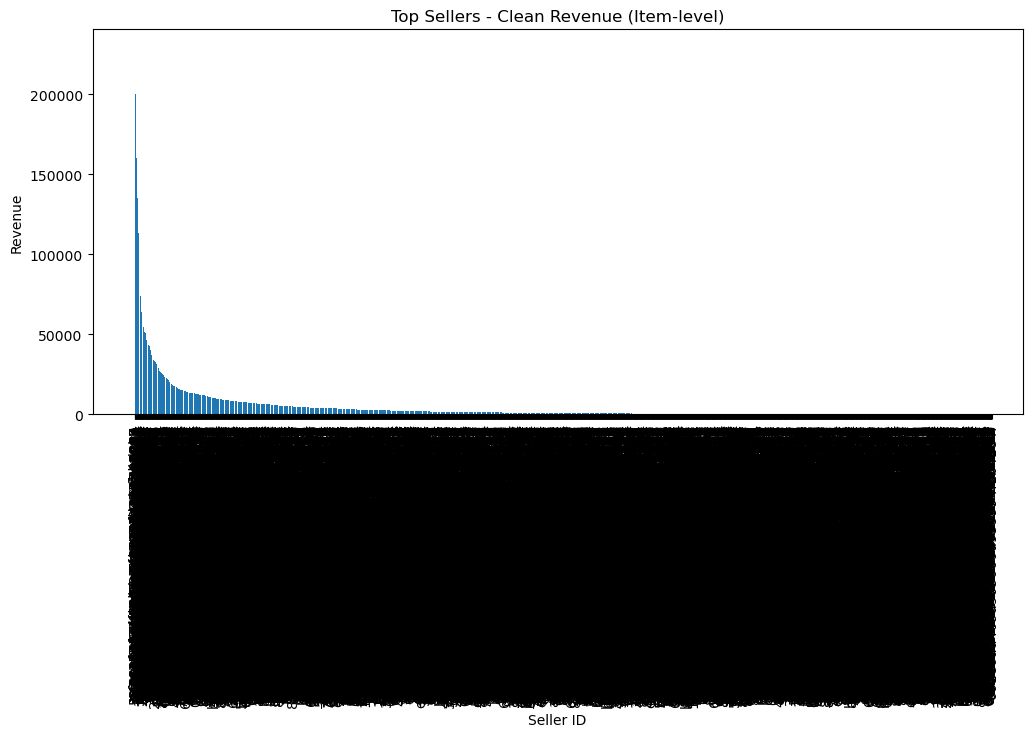

In [396]:
top_revenue = check.sort_values("clean_revenue", ascending=False).head(3095)

plt.figure(figsize=(12,5))
plt.bar(top_revenue["seller_id"], top_revenue["clean_revenue"])
plt.xticks(rotation=90)
plt.title("Top Sellers - Clean Revenue (Item-level)")
plt.ylabel("Revenue")
plt.xlabel("Seller ID")
plt.show()

In [242]:
# Delivery time distribution
query = """SELECT order_id, order_purchase_timestamp::TIMESTAMP AS purchase_timestamp, 
order_delivered_customer_date::TIMESTAMP AS delivered_timestamp, 
EXTRACT(DAY FROM (order_delivered_customer_date::TIMESTAMP - order_purchase_timestamp::TIMESTAMP)) AS Delivery_Days
FROM olist_orders_dataset
WHERE order_purchase_timestamp IS NOT NULL
AND order_delivered_customer_date IS NOT NULL
AND order_delivered_customer_date::TIMESTAMP >= order_purchase_timestamp::TIMESTAMP"""
check = pd.read_sql(query, engine)
check

,order_id,purchase_timestamp,delivered_timestamp,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0
...,...,...,...,...
96471,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:05,2017-03-17 15:08:01,8.0
96472,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58,2018-02-28 17:37:56,22.0
96473,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43,2017-09-21 11:24:17,24.0
96474,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,2018-01-25 23:32:54,17.0


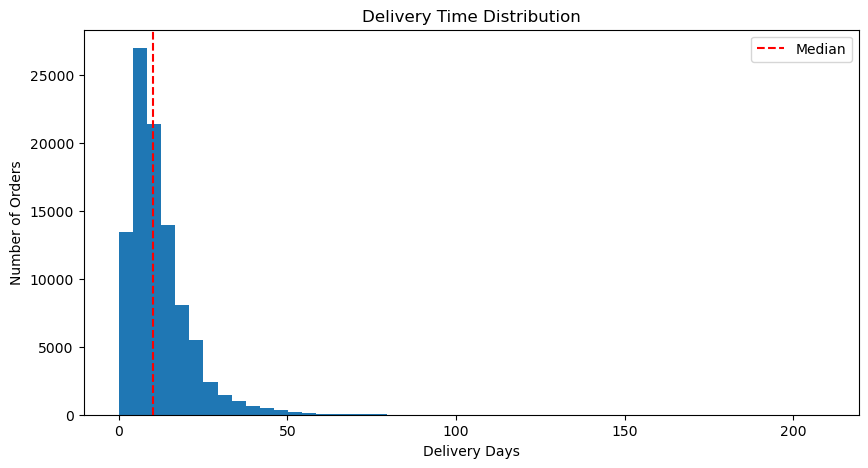

In [243]:
plt.figure(figsize=(10,5))
plt.hist(check["delivery_days"], bins=50)
plt.axvline(check["delivery_days"].median(), color='red', linestyle='--', label='Median')
plt.legend()
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.show()

In [248]:
# Late delivery by state
# order_purchase_timestamp --> no null value
query = """SELECT c.customer_state, 
COUNT(*) AS total_delivered_orders,
COUNT(*) FILTER (WHERE o.order_delivered_customer_date IS NOT NULL
AND o.order_estimated_delivery_date IS NOT NULL
AND o.order_delivered_customer_date > o.order_estimated_delivery_date) AS late_orders,
100.0 * COUNT(*) FILTER (WHERE o.order_delivered_customer_date IS NOT NULL
AND o.order_estimated_delivery_date IS NOT NULL
AND o.order_delivered_customer_date > o.order_estimated_delivery_date) / COUNT(*) AS late_delivery_rate
FROM olist_orders_dataset o
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY late_delivery_rate DESC;"""
check = pd.read_sql(query, engine)
check

,customer_state,total_delivered_orders,late_orders,late_delivery_rate
0,AL,397,95,23.929471
1,MA,717,141,19.665272
2,PI,476,76,15.966387
3,CE,1279,196,15.324472
4,SE,335,51,15.223881
5,BA,3256,457,14.035627
6,RJ,12350,1664,13.473684
7,TO,274,35,12.773723
8,PA,946,117,12.367865
9,ES,1995,244,12.230576


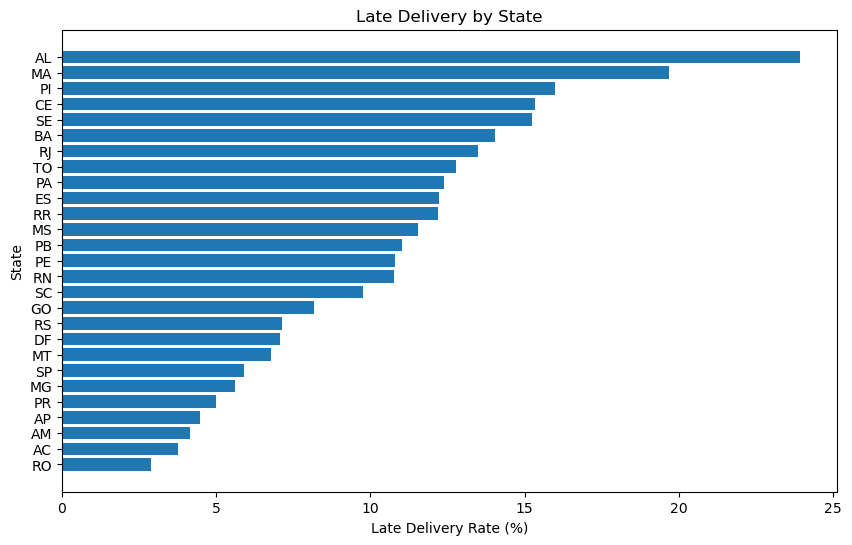

In [254]:
plt.figure(figsize=(10,6))

plt.barh(
    check["customer_state"],
    check["late_delivery_rate"]
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("State")
plt.title("Late Delivery by State")
plt.gca().invert_yaxis()
plt.show()

In [285]:
# quadrant
# order_purchase_timestamp --> no null value
query = """WITH payment_agg AS (
SELECT order_id, SUM(payment_value) AS total_payment
FROM olist_order_payments_dataset
GROUP BY order_id)
SELECT TRIM(LOWER(c.customer_city)) AS customer_city,
COUNT(DISTINCT o.order_id) AS total_delivered_orders,
COUNT(DISTINCT o.order_id) FILTER (WHERE o.order_delivered_customer_date IS NOT NULL
AND o.order_estimated_delivery_date IS NOT NULL
AND o.order_delivered_customer_date > o.order_estimated_delivery_date) AS late_orders,
100.0 * COUNT(DISTINCT o.order_id) FILTER (WHERE o.order_delivered_customer_date IS NOT NULL
AND o.order_estimated_delivery_date IS NOT NULL
AND o.order_delivered_customer_date > o.order_estimated_delivery_date) / COUNT(DISTINCT o.order_id) AS late_delivery_rate,
SUM(p.total_payment) * 1.0 / COUNT(DISTINCT o.order_id) AS aov
FROM olist_orders_dataset o
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
JOIN payment_agg p
ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY TRIM(LOWER(c.customer_city))
ORDER BY late_delivery_rate DESC;"""
check = pd.read_sql(query, engine)
check

,customer_city,total_delivered_orders,late_orders,late_delivery_rate,aov
0,medicilandia,1,1,100.0,43.1400
1,glaura,1,1,100.0,89.3600
2,gilbues,1,1,100.0,356.5100
3,conceicao da ibitipoca,1,1,100.0,55.0900
4,lamim,1,1,100.0,108.6300
...,...,...,...,...,...
4080,jacinto machado,4,0,0.0,111.7925
4081,jacui,4,0,0.0,118.9675
4082,jacunda,6,0,0.0,307.4700
4083,jacupiranga,5,0,0.0,177.1140


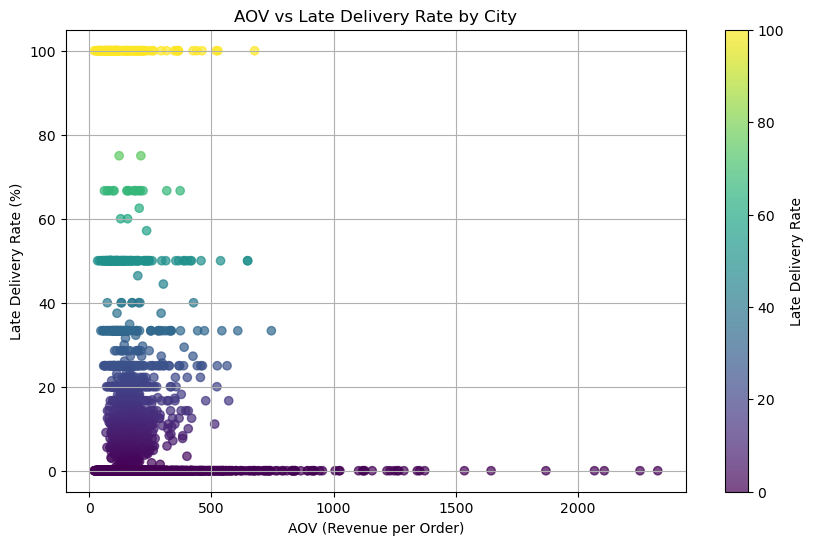

In [286]:
plt.figure(figsize=(10,6))

plt.scatter(
    check["aov"],
    check["late_delivery_rate"],
    c=check["late_delivery_rate"],   # gradient color
    cmap="viridis",
    alpha=0.7
)
plt.colorbar(label="Late Delivery Rate")

plt.xlabel("AOV (Revenue per Order)")
plt.ylabel("Late Delivery Rate (%)")
plt.title("AOV vs Late Delivery Rate by City")

plt.grid(True)
plt.show()

In [287]:
x_mid = check["aov"].median()
y_mid = check["late_delivery_rate"].median()
def get_quadrant(row):
    if row["aov"] >= x_mid and row["late_delivery_rate"] < y_mid:
        return "High AOV - Low Delay (Best)"
    elif row["aov"] >= x_mid and row["late_delivery_rate"] >= y_mid:
        return "High AOV - High Delay (Risk)"
    elif row["aov"] < x_mid and row["late_delivery_rate"] < y_mid:
        return "Low AOV - Low Delay (Stable)"
    else:
        return "Low AOV - High Delay (Worst)"
check["quadrant"] = check.apply(get_quadrant, axis=1)
check.groupby("quadrant")["customer_city"].apply(list)

quadrant
High AOV - High Delay (Risk)    [gilbues, adhemar de barros, maioba, ribeiro j...
Low AOV - High Delay (Worst)    [medicilandia, glaura, conceicao da ibitipoca,...
Name: customer_city, dtype: object

In [292]:
query = """WITH base AS (
SELECT oi.order_id, oi.product_id,
COALESCE(p.product_category_name, 'Other') AS product_category_name,
o.order_delivered_customer_date,
o.order_estimated_delivery_date
FROM olist_order_items_dataset oi
JOIN olist_products_dataset p
ON oi.product_id = p.product_id
JOIN olist_orders_dataset o
ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered')
SELECT product_category_name, COUNT(*) AS total_delivered_items,
COUNT(*) FILTER (WHERE order_delivered_customer_date IS NOT NULL
AND order_estimated_delivery_date IS NOT NULL
AND order_delivered_customer_date > order_estimated_delivery_date) AS late_items,
100.0 * COUNT(*) FILTER (WHERE order_delivered_customer_date IS NOT NULL
AND order_estimated_delivery_date IS NOT NULL
AND order_delivered_customer_date > order_estimated_delivery_date) / COUNT(*) AS late_delivery_rate
FROM base
GROUP BY product_category_name
ORDER BY late_delivery_rate DESC;
"""
df = pd.read_sql(query, engine)
df

,product_category_name,total_delivered_items,late_items,late_delivery_rate
0,casa_conforto_2,30,5,16.666667
1,moveis_colchao_e_estofado,37,5,13.513514
2,audio,362,46,12.707182
3,fashion_underwear_e_moda_praia,127,16,12.598425
4,artigos_de_natal,150,18,12.000000
...,...,...,...,...
69,pc_gamer,8,0,0.000000
70,cds_dvds_musicais,14,0,0.000000
71,la_cuisine,14,0,0.000000
72,fashion_roupa_infanto_juvenil,7,0,0.000000


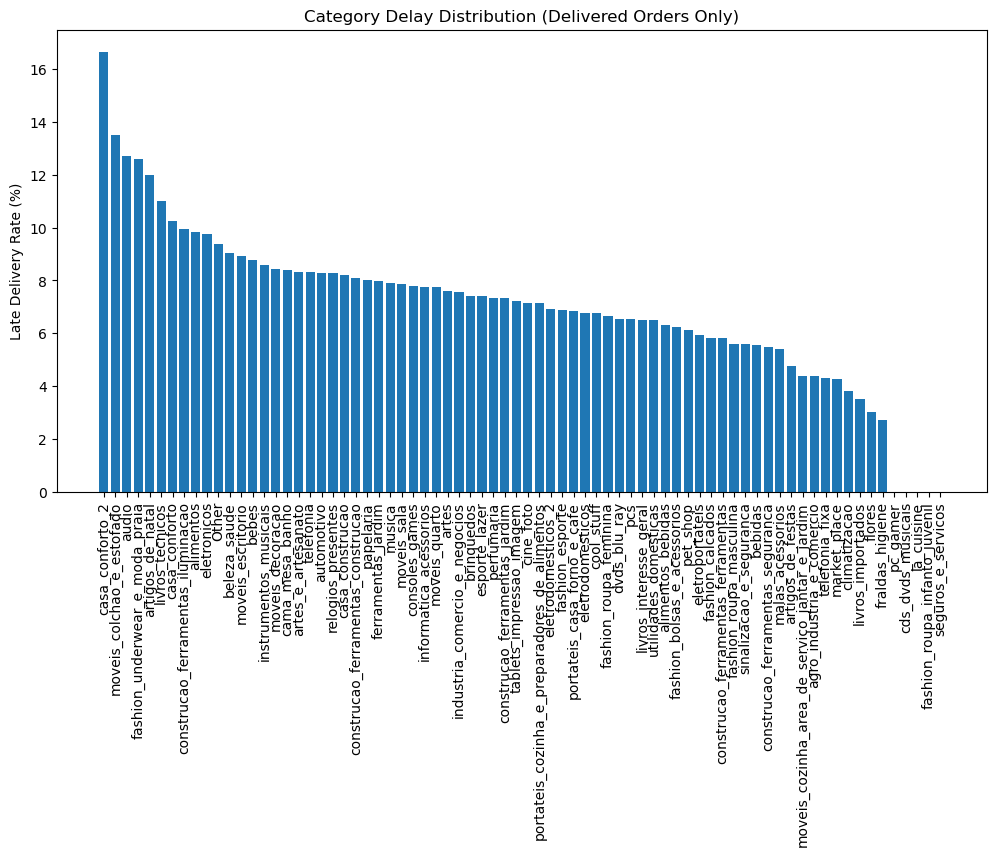

In [293]:
plt.figure(figsize=(12,6))
plt.bar(df["product_category_name"], df["late_delivery_rate"])
plt.xticks(rotation=90)
plt.ylabel("Late Delivery Rate (%)")
plt.title("Category Delay Distribution (Delivered Orders Only)")
plt.show()

In [429]:
# Seller Delay Rate
# all sellers are active i.e atleast one sales 
query = """WITH base AS (
SELECT oi.order_id, oi.seller_id, o.order_delivered_customer_date, o.order_estimated_delivery_date
FROM olist_order_items_dataset oi
JOIN olist_orders_dataset o
ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered')
SELECT seller_id, COUNT(*) AS total_items,
COUNT(*) FILTER (WHERE order_delivered_customer_date IS NOT NULL
AND order_estimated_delivery_date IS NOT NULL
AND order_delivered_customer_date > order_estimated_delivery_date) AS late_items,
100.0 * COUNT(*) FILTER (WHERE order_delivered_customer_date IS NOT NULL
AND order_estimated_delivery_date IS NOT NULL
AND order_delivered_customer_date > order_estimated_delivery_date) / COUNT(*) AS late_delivery_rate
FROM base
GROUP BY seller_id
ORDER BY late_delivery_rate DESC;
"""
check = pd.read_sql(query, engine)
check

,seller_id,total_items,late_items,late_delivery_rate
0,1352e06ae67b410cdae0b2a22361167b,2,2,100.0
1,685b870da5b52a710782c9c0fefbeb5b,2,2,100.0
2,2a50b7ee5aebecc6fd0ff9784a4747d6,2,2,100.0
3,9c57bc60cfad5ee62d35d3f1ce4593a1,1,1,100.0
4,9bf11dfc0bec77e5a23028043c3c5a8f,1,1,100.0
...,...,...,...,...
2965,96f7c797de9ca20efbe14545bed63eec,3,0,0.0
2966,1e47d8b6546eb3a77b1acddcc9406242,1,0,0.0
2967,8cf21434553b02cbd37c0bbd07e041b0,1,0,0.0
2968,bc30de0d71bd6260b936a026b5cf7200,3,0,0.0


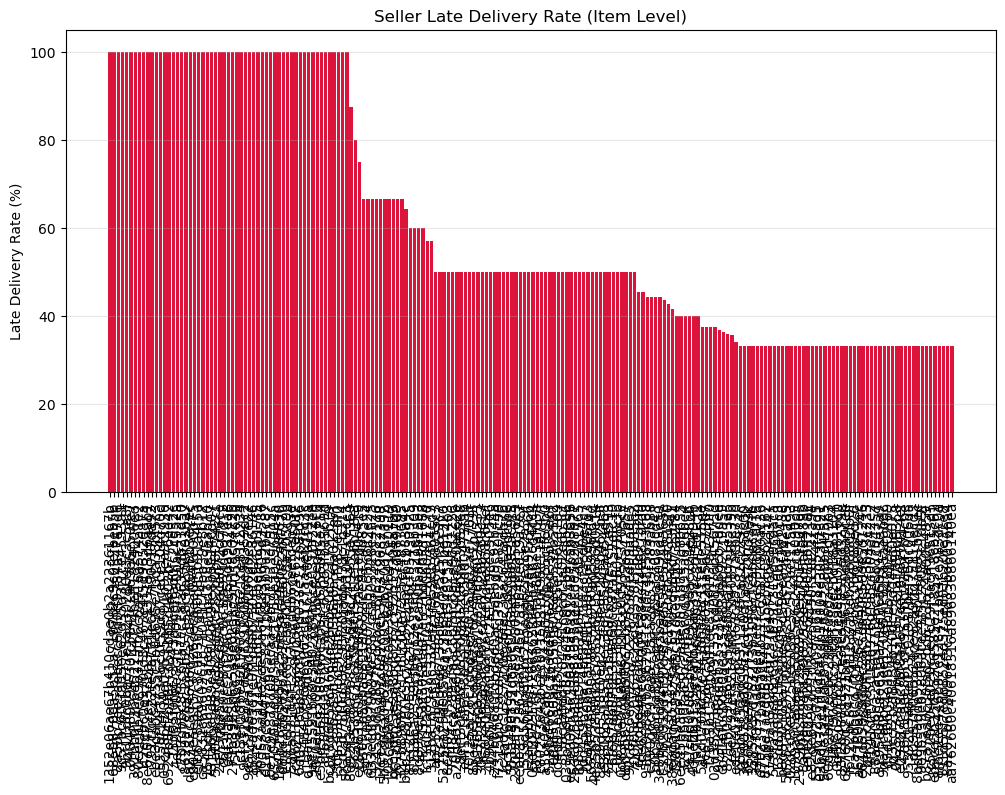

In [430]:
plot_df = check.head(200)

plt.figure(figsize=(12,6))

plt.bar(plot_df["seller_id"], plot_df["late_delivery_rate"], color="crimson")

plt.xticks(rotation=90)
plt.ylabel("Late Delivery Rate (%)")
plt.title("Seller Late Delivery Rate (Item Level)")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [439]:
query = """WITH cte AS (
SELECT order_id, review_score, 
ROW_NUMBER() OVER(PARTITION BY order_id ORDER BY review_answer_timestamp::TIMESTAMP DESC) AS rn
FROM olist_order_reviews_dataset),

base AS (
SELECT order_id, order_delivered_customer_date::TIMESTAMP, order_estimated_delivery_date::TIMESTAMP,
EXTRACT(DAYS FROM (order_delivered_customer_date::TIMESTAMP - order_estimated_delivery_date::TIMESTAMP)) AS delay_days
FROM olist_orders_dataset
WHERE order_status = 'delivered'),
review_clean AS (
SELECT order_id, review_score
FROM cte
WHERE rn = 1),

bucketed AS (
SELECT base.order_id, review_score,
CASE 
WHEN delay_days <= -2 THEN 'Very Early'
WHEN delay_days = -1 THEN 'Early'
WHEN delay_days = 0 THEN 'On-time'
WHEN delay_days = 1 THEN 'Late'
ELSE 'Very Late'
END AS delivery_bucket
FROM base
JOIN review_clean
ON base.order_id = review_clean.order_id)
SELECT  delivery_bucket,
COUNT(*) FILTER (WHERE review_score = 1) AS score_1,
COUNT(*) FILTER (WHERE review_score = 2) AS score_2,
COUNT(*) FILTER (WHERE review_score = 3) AS score_3,
COUNT(*) FILTER (WHERE review_score = 4) AS score_4,
COUNT(*) FILTER (WHERE review_score = 5) AS score_5 
FROM bucketed
GROUP BY delivery_bucket
ORDER BY CASE delivery_bucket
WHEN 'Very Early' THEN 1
WHEN 'Early' THEN 2
WHEN 'On-time' THEN 3
WHEN 'Late' THEN 4
ELSE 5
END;"""
check = pd.read_sql(query, engine)
check

,delivery_bucket,score_1,score_2,score_3,score_4,score_5
0,Very Early,5575,2214,6723,17274,53387
1,Early,128,53,173,333,853
2,On-time,217,102,326,632,1453
3,Late,107,54,124,202,333
4,Very Late,3325,498,570,447,729


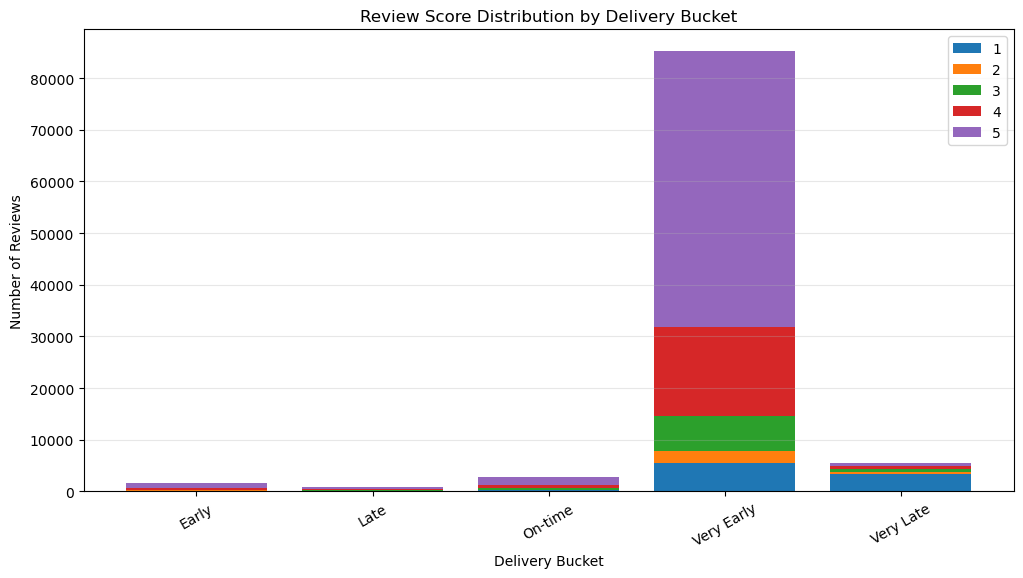

In [440]:
check = check.sort_values("delivery_bucket")

plt.figure(figsize=(12,6))

plt.bar(check["delivery_bucket"], check["score_1"], label="1")
plt.bar(check["delivery_bucket"], check["score_2"], bottom=check["score_1"], label="2")
plt.bar(check["delivery_bucket"], check["score_3"], 
        bottom=check["score_1"] + check["score_2"], label="3")
plt.bar(check["delivery_bucket"], check["score_4"], 
        bottom=check["score_1"] + check["score_2"] + check["score_3"], label="4")
plt.bar(check["delivery_bucket"], check["score_5"], 
        bottom=check["score_1"] + check["score_2"] + check["score_3"] + check["score_4"], 
        label="5")

plt.xlabel("Delivery Bucket")
plt.ylabel("Number of Reviews")
plt.title("Review Score Distribution by Delivery Bucket")

plt.xticks(rotation=30)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

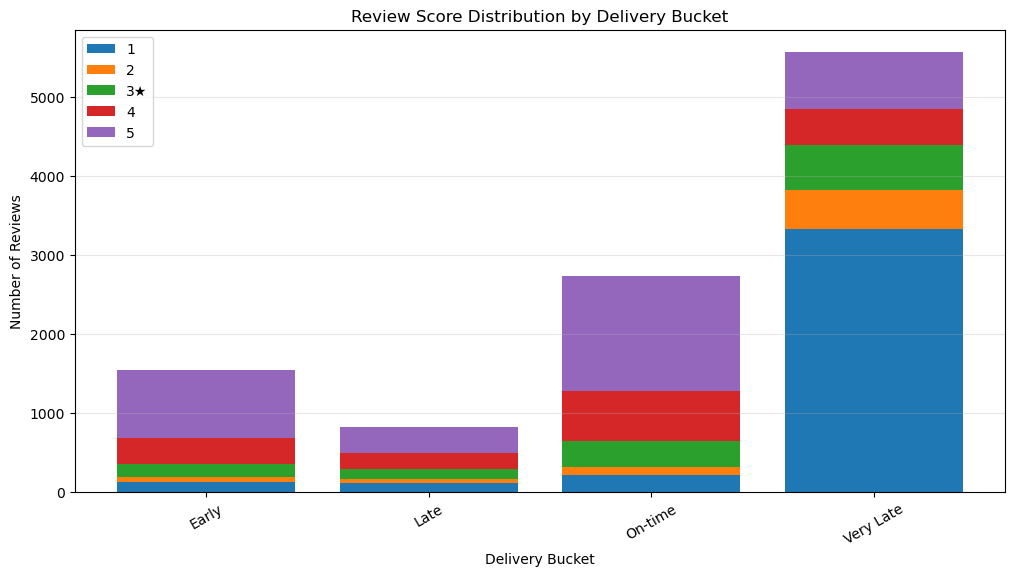

In [441]:
check = check[check["delivery_bucket"] != "Very Early"].copy()
check = check.sort_values("delivery_bucket")

plt.figure(figsize=(12,6))

plt.bar(check["delivery_bucket"], check["score_1"], label="1")
plt.bar(check["delivery_bucket"], check["score_2"], bottom=check["score_1"], label="2")
plt.bar(check["delivery_bucket"], check["score_3"], 
        bottom=check["score_1"] + check["score_2"], label="3★")
plt.bar(check["delivery_bucket"], check["score_4"], 
        bottom=check["score_1"] + check["score_2"] + check["score_3"], label="4")
plt.bar(check["delivery_bucket"], check["score_5"], 
        bottom=check["score_1"] + check["score_2"] + check["score_3"] + check["score_4"], 
        label="5")

plt.xlabel("Delivery Bucket")
plt.ylabel("Number of Reviews")
plt.title("Review Score Distribution by Delivery Bucket")

plt.xticks(rotation=30)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [442]:
# Survey response time buckets vs review score
query = """WITH base AS (
SELECT r.order_id, r.review_score, (r.review_answer_timestamp::date - o.order_delivered_customer_date::date) AS response_days
FROM olist_order_reviews_dataset r
JOIN olist_orders_dataset o
ON r.order_id = o.order_id
WHERE o.order_status = 'delivered'),

bucketed AS (
SELECT *,
CASE 
WHEN response_days = 0 THEN 'Same Day'
WHEN response_days = 1 THEN 'Next Day'
WHEN response_days BETWEEN 2 AND 3 THEN '2-3 Days'
WHEN response_days BETWEEN 4 AND 7 THEN '4-7 Days'
ELSE '7+ Days'
END AS time_bucket
FROM base)

SELECT time_bucket,
COUNT(*) FILTER (WHERE review_score = 1) AS score_1,
COUNT(*) FILTER (WHERE review_score = 2) AS score_2,
COUNT(*) FILTER (WHERE review_score = 3) AS score_3,
COUNT(*) FILTER (WHERE review_score = 4) AS score_4,
COUNT(*) FILTER (WHERE review_score = 5) AS score_5
FROM bucketed
GROUP BY time_bucket
ORDER BY 
CASE time_bucket
WHEN 'Same Day' THEN 1
WHEN 'Next Day' THEN 2
WHEN '2-3 Days' THEN 3
WHEN '4-7 Days' THEN 4
ELSE 5
END;"""
check = pd.read_sql(query, engine)
check

,time_bucket,score_1,score_2,score_3,score_4,score_5
0,Same Day,326,61,141,227,640
1,Next Day,1362,512,1571,3717,12598
2,2-3 Days,2801,1167,3556,9048,27207
3,4-7 Days,1448,623,1904,4713,13147
4,7+ Days,3469,578,789,1282,3474


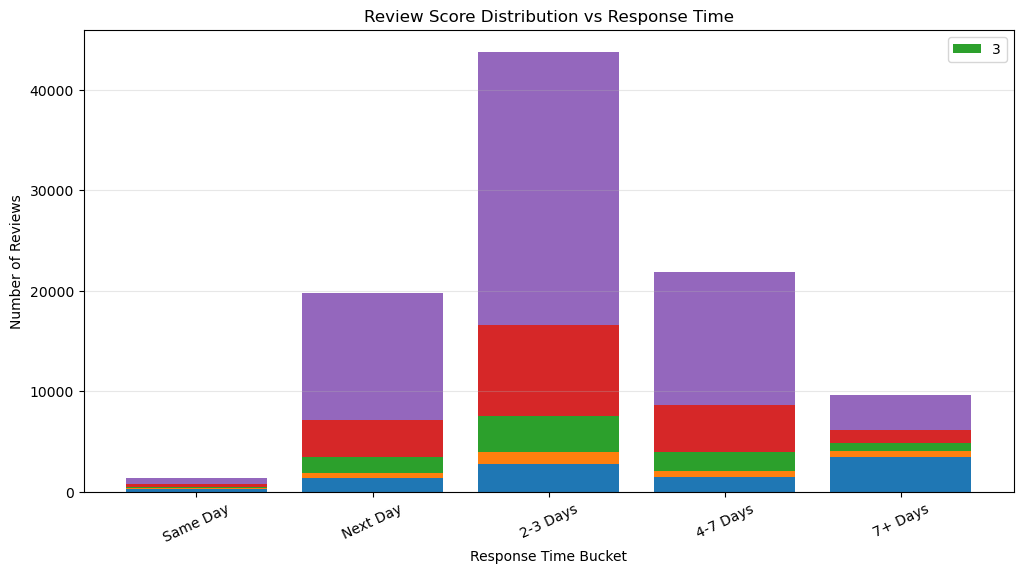

In [443]:
plt.figure(figsize=(12,6))

plt.bar(check["time_bucket"], check["score_1"], label="")
plt.bar(check["time_bucket"], check["score_2"], bottom=check["score_1"], label="")
plt.bar(check["time_bucket"], check["score_3"], 
        bottom=check["score_1"] + check["score_2"], label="3")
plt.bar(check["time_bucket"], check["score_4"], 
        bottom=check["score_1"] + check["score_2"] + check["score_3"], label="")
plt.bar(check["time_bucket"], check["score_5"], 
        bottom=check["score_1"] + check["score_2"] + check["score_3"] + check["score_4"], 
        label="")

plt.xlabel("Response Time Bucket")
plt.ylabel("Number of Reviews")
plt.title("Review Score Distribution vs Response Time")

plt.xticks(rotation=25)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

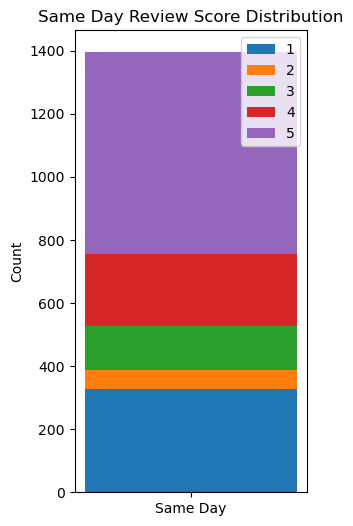

In [444]:
same_day = check[check["time_bucket"] == "Same Day"]

plt.figure(figsize=(3,6))
plt.bar("Same Day", same_day["score_1"].iloc[0], label="1")
plt.bar("Same Day", same_day["score_2"].iloc[0],
        bottom=same_day["score_1"].iloc[0], label="2")
plt.bar("Same Day", same_day["score_3"].iloc[0],
        bottom=same_day["score_1"].iloc[0] + same_day["score_2"].iloc[0], label="3")
plt.bar("Same Day", same_day["score_4"].iloc[0],
        bottom=same_day["score_1"].iloc[0] + same_day["score_2"].iloc[0] + same_day["score_3"].iloc[0], label="4")
plt.bar("Same Day", same_day["score_5"].iloc[0],
        bottom=same_day["score_1"].iloc[0] + same_day["score_2"].iloc[0] + same_day["score_3"].iloc[0] + same_day["score_4"].iloc[0],
        label="5")

plt.ylabel("Count")
plt.title("Same Day Review Score Distribution")
plt.legend()

plt.show()

In [421]:
# Overall review score distribution
query = """
WITH review_clean AS (
SELECT r.order_id, r.review_score,
ROW_NUMBER() OVER (PARTITION BY r.order_id ORDER BY r.review_answer_timestamp DESC) AS rn
FROM olist_order_reviews_dataset r),

base AS (
SELECT rc.order_id, rc.review_score
FROM review_clean rc
JOIN olist_orders_dataset o
ON rc.order_id = o.order_id
WHERE o.order_status = 'delivered'
AND rc.rn = 1)

SELECT review_score, COUNT(*) AS total_orders
FROM base
GROUP BY review_score
ORDER BY review_score;"""
check = pd.read_sql(query, engine)
check

,review_score,total_orders
0,1,9352
1,2,2921
2,3,7916
3,4,18888
4,5,56755


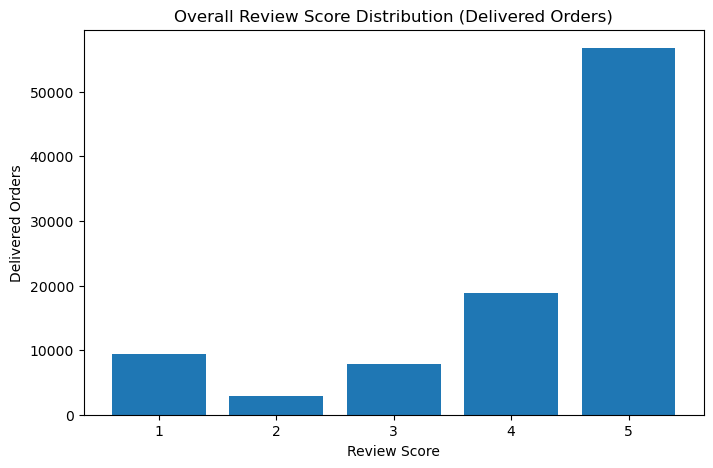

In [337]:
plt.figure(figsize=(8,5))
plt.bar(check["review_score"], check["total_orders"])
plt.xlabel("Review Score")
plt.ylabel("Delivered Orders")
plt.title("Overall Review Score Distribution (Delivered Orders)")
plt.show()

In [446]:
# Review Score Distribution by Product Category
query = """WITH review_clean AS (
SELECT order_id, review_score,
ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY review_answer_timestamp DESC) AS rn
FROM olist_order_reviews_dataset),

category_orders AS (SELECT oi.order_id,
COALESCE(p.product_category_name, 'Other') AS product_category_name
FROM olist_order_items_dataset oi
JOIN olist_products_dataset p
ON oi.product_id = p.product_id),

base AS (SELECT co.product_category_name, rc.review_score
FROM category_orders co
JOIN olist_orders_dataset o
ON co.order_id = o.order_id
JOIN review_clean rc
ON co.order_id = rc.order_id
WHERE o.order_status = 'delivered'
AND rc.rn = 1)

SELECT product_category_name,
COUNT(*) FILTER (WHERE review_score = 1) AS score_1,
COUNT(*) FILTER (WHERE review_score = 2) AS score_2,
COUNT(*) FILTER (WHERE review_score = 3) AS score_3,
COUNT(*) FILTER (WHERE review_score = 4) AS score_4,
COUNT(*) FILTER (WHERE review_score = 5) AS score_5,
COUNT(*) AS total_reviews
FROM base
GROUP BY product_category_name
ORDER BY total_reviews DESC;"""
check = pd.read_sql(query, engine)
check

,product_category_name,score_1,score_2,score_3,score_4,score_5,total_reviews
0,cama_mesa_banho,1496,476,1079,2085,5695,10831
1,beleza_saude,945,229,733,1687,5808,9402
2,esporte_lazer,870,222,619,1609,5058,8378
3,moveis_decoracao,1118,344,733,1488,4397,8080
4,informatica_acessorios,1032,264,633,1522,4157,7608
...,...,...,...,...,...,...,...
69,portateis_cozinha_e_preparadores_de_alimentos,2,2,3,2,5,14
70,la_cuisine,3,0,0,1,9,13
71,pc_gamer,2,0,0,3,3,8
72,fashion_roupa_infanto_juvenil,0,0,0,0,7,7


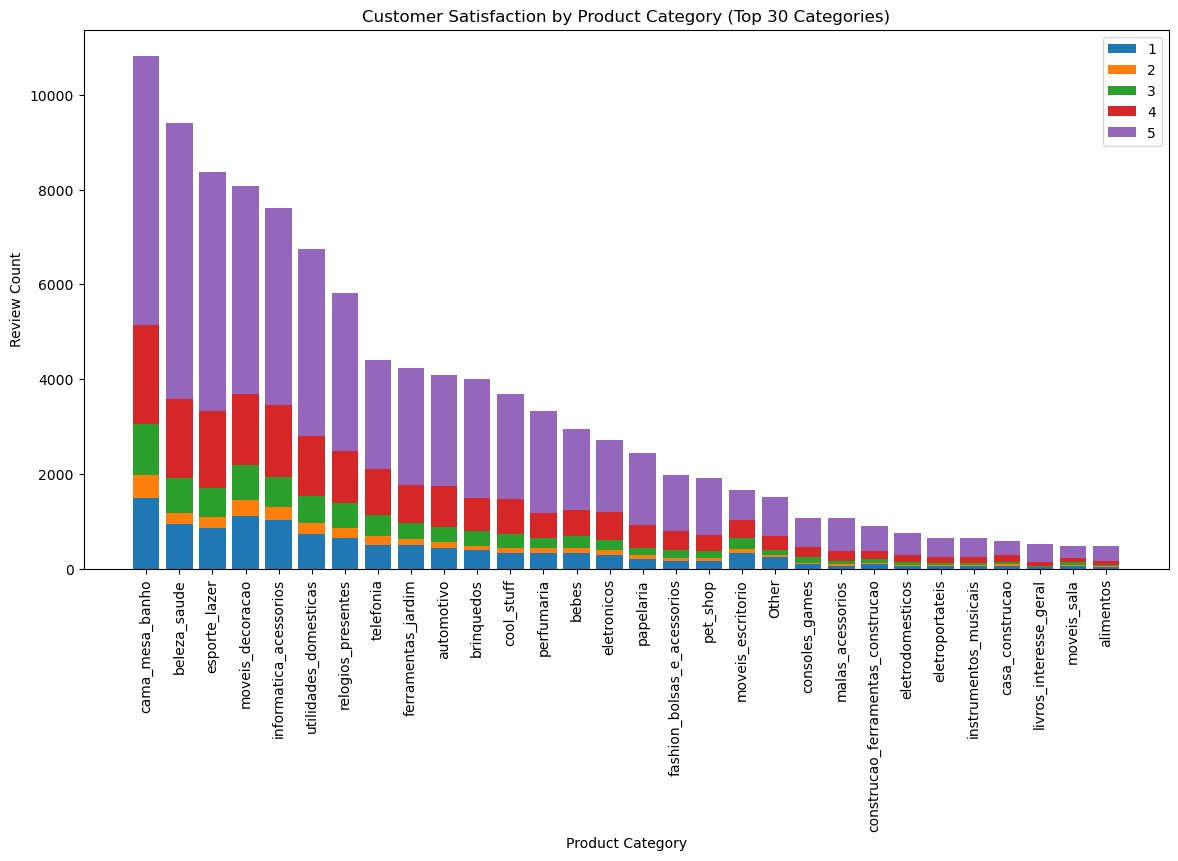

In [447]:
top = check.head(30)

plt.figure(figsize=(14,7))

plt.bar(top["product_category_name"], top["score_1"], label="1")
plt.bar(top["product_category_name"], top["score_2"],
        bottom=top["score_1"], label="2")
plt.bar(top["product_category_name"], top["score_3"],
        bottom=top["score_1"] + top["score_2"], label="3")
plt.bar(top["product_category_name"], top["score_4"],
        bottom=top["score_1"] + top["score_2"] + top["score_3"], label="4")
plt.bar(top["product_category_name"], top["score_5"],
        bottom=top["score_1"] + top["score_2"] + top["score_3"] + top["score_4"],
        label="5")

plt.xticks(rotation=90)
plt.xlabel("Product Category")
plt.ylabel("Review Count")
plt.title("Customer Satisfaction by Product Category (Top 30 Categories)")
plt.legend()

plt.show()

In [351]:
# Product photo impact on sales and reviews
query = """WITH base AS (
SELECT
CASE
WHEN p.product_photos_qty = 1 THEN '1'
WHEN p.product_photos_qty BETWEEN 2 AND 3 THEN '2-3'
WHEN p.product_photos_qty BETWEEN 4 AND 6 THEN '4-6'
WHEN p.product_photos_qty BETWEEN 7 AND 10 THEN '7-10'
ELSE '11-20'
END AS photo_bucket
FROM olist_order_items_dataset oi
JOIN olist_products_dataset p
ON oi.product_id = p.product_id
WHERE p.product_photos_qty IS NOT NULL)
SELECT photo_bucket, COUNT(*) AS items_sold
FROM base
GROUP BY photo_bucket
ORDER BY
CASE photo_bucket
WHEN '1' THEN 1
WHEN '2-3' THEN 2
WHEN '4-6' THEN 3
WHEN '7-10' THEN 4
ELSE 5
END;"""
check = pd.read_sql(query, engine)
check

,photo_bucket,items_sold
0,1,56028
1,2-3,34355
2,4-6,17591
3,7-10,2883
4,11-20,190


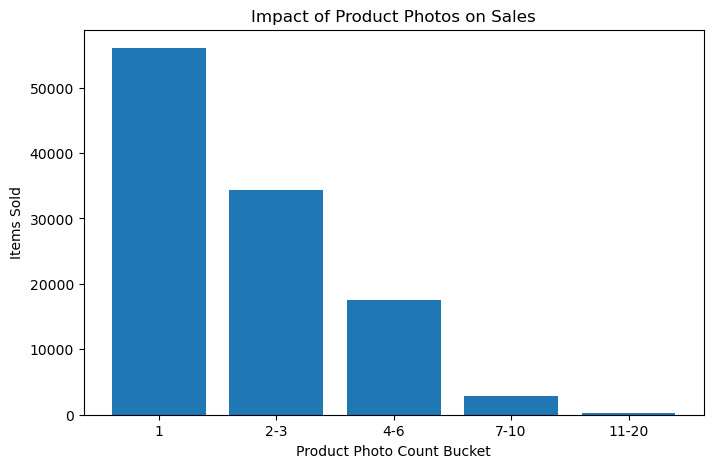

In [352]:
plt.figure(figsize=(8,5))

plt.bar(check["photo_bucket"], check["items_sold"])

plt.xlabel("Product Photo Count Bucket")
plt.ylabel("Items Sold")
plt.title("Impact of Product Photos on Sales")

plt.show()

In [354]:
query = """SELECT product_photos_qty,
COUNT(*) AS total_products
FROM olist_products_dataset
WHERE product_photos_qty IS NOT NULL
GROUP BY product_photos_qty
ORDER BY product_photos_qty;
"""
check = pd.read_sql(query, engine)
check

,product_photos_qty,total_products
0,1.0,16489
1,2.0,6263
2,3.0,3860
3,4.0,2428
4,5.0,1484
5,6.0,968
6,7.0,343
7,8.0,192
8,9.0,105
9,10.0,95


In [355]:
# Higher sales in low photo-count buckets are likely driven by the larger number of products present in those buckets. 
# This analysis shows an association, not the effect of product photos on sales.

In [359]:
# Category Composition of Repeat Purchases (item level)
query = """
WITH valid_orders AS (
SELECT o.order_id, c.customer_unique_id, o.order_purchase_timestamp,
ROW_NUMBER() OVER (
PARTITION BY c.customer_unique_id
ORDER BY o.order_purchase_timestamp) AS rn
FROM olist_orders_dataset o
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
WHERE o.order_status NOT IN ('canceled', 'unavailable')),
repeat_orders AS (
SELECT order_id
FROM valid_orders
WHERE rn > 1),
base AS (
SELECT COALESCE(p.product_category_name, 'Other') AS product_category_name, ro.order_id
FROM repeat_orders ro
JOIN olist_order_items_dataset oi
ON ro.order_id = oi.order_id
JOIN olist_products_dataset p
ON oi.product_id = p.product_id)

SELECT product_category_name, COUNT(*) AS repeat_items,
100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS share_pct
FROM base
GROUP BY product_category_name
ORDER BY repeat_items DESC;"""
check = pd.read_sql(query, engine)
check

,product_category_name,repeat_items,share_pct
0,cama_mesa_banho,594,15.211268
1,moveis_decoracao,402,10.294494
2,esporte_lazer,357,9.142125
3,informatica_acessorios,298,7.631242
4,beleza_saude,296,7.580026
...,...,...,...
63,fashion_roupa_infanto_juvenil,1,0.025608
64,pc_gamer,1,0.025608
65,casa_conforto_2,1,0.025608
66,artigos_de_festas,1,0.025608


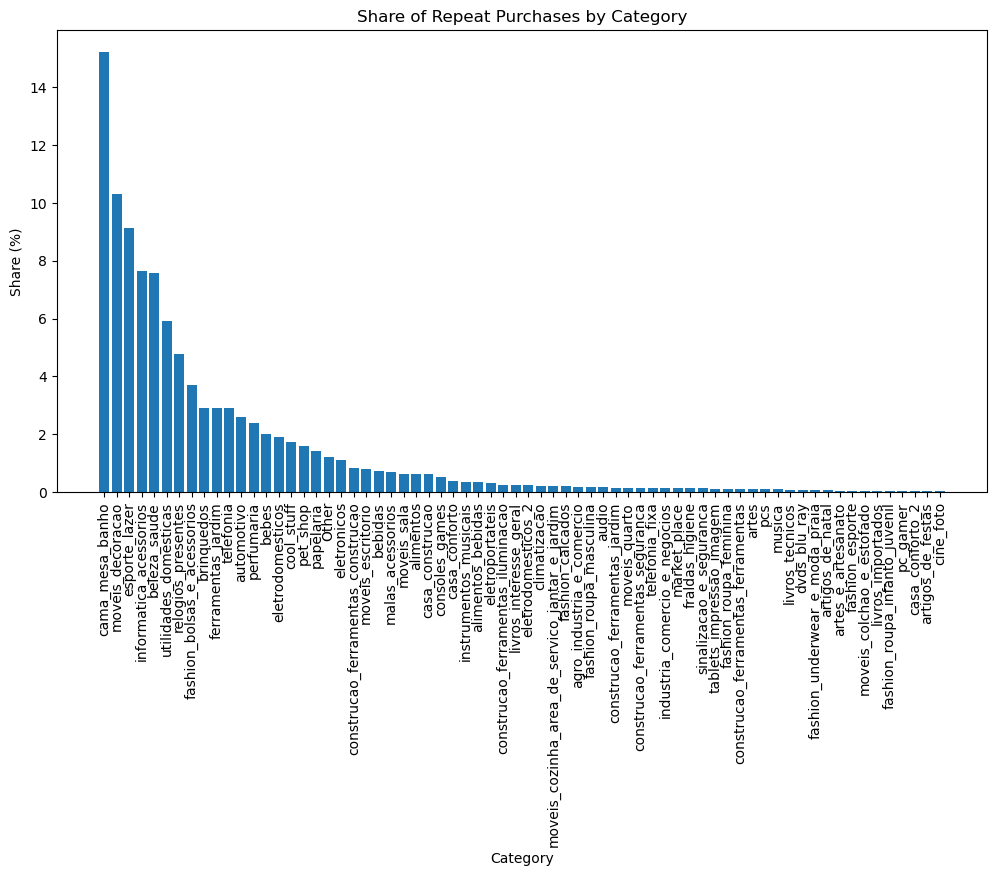

In [365]:
top = check.head(68)

plt.figure(figsize=(12,6))

plt.bar(top["product_category_name"], top["share_pct"])

plt.xticks(rotation=90)
plt.xlabel("Category")
plt.ylabel("Share (%)")
plt.title("Share of Repeat Purchases by Category")

plt.show()

In [386]:
# Payment Type Breakdown (Usage Share)
query = """SELECT payment_type,
COUNT(*) AS payment_count,
100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS share_pct
FROM olist_order_payments_dataset
WHERE payment_value > 0
GROUP BY payment_type
ORDER BY payment_count DESC;"""
check = pd.read_sql(query, engine)
check
# not_defined payment type is deleted due to filter along with the 0 payment value rows

,payment_type,payment_count,share_pct
0,credit_card,76795,73.928781
1,boleto,19784,19.045602
2,voucher,5769,5.553684
3,debit_card,1529,1.471933


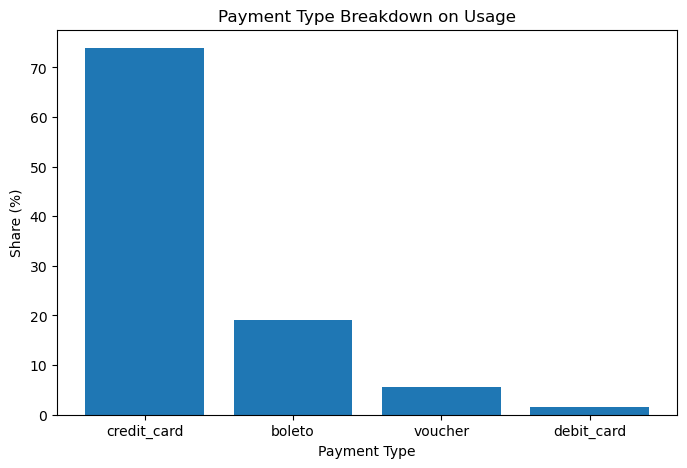

In [387]:
plt.figure(figsize=(8,5))
plt.bar(check["payment_type"], check["share_pct"])
plt.xlabel("Payment Type")
plt.ylabel("Share (%)")
plt.title("Payment Type Breakdown on Usage")

plt.show()

In [377]:
#  Value Share
query = """SELECT payment_type,
SUM(payment_value) AS total_payment_value,
100.0 * SUM(payment_value) / SUM(SUM(payment_value)) OVER () AS value_share_pct
FROM olist_order_payments_dataset
GROUP BY payment_type
ORDER BY total_payment_value DESC;"""
check = pd.read_sql(query, engine)
check

,payment_type,total_payment_value,value_share_pct
0,credit_card,1.254208e+07,78.344584
1,boleto,2.869361e+06,17.923569
2,voucher,3.794369e+05,2.370166
3,debit_card,2.179898e+05,1.361681
4,not_defined,0.000000e+00,0.000000


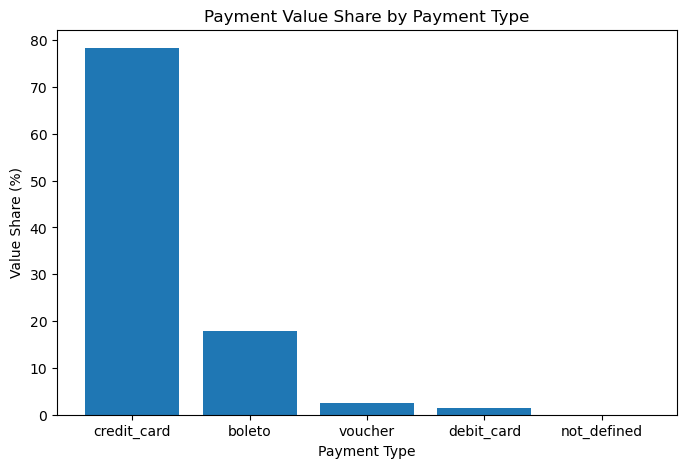

In [378]:
plt.figure(figsize=(8,5))
plt.bar(check["payment_type"], check["value_share_pct"])
plt.xlabel("Payment Type")
plt.ylabel("Value Share (%)")
plt.title("Payment Value Share by Payment Type")

plt.show()

In [389]:
# Installment Behaivior
query = """WITH bucketed AS (
SELECT
CASE
WHEN payment_installments = 1 THEN '1'
WHEN payment_installments BETWEEN 2 AND 3 THEN '2-3'
WHEN payment_installments BETWEEN 4 AND 6 THEN '4-6'
WHEN payment_installments BETWEEN 7 AND 12 THEN '7-12'
ELSE '13+'
END AS installment_bucket
FROM olist_order_payments_dataset
WHERE payment_value > 0 AND payment_installments > 0)

SELECT installment_bucket, COUNT(*) AS payment_count,
100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS share_pct
FROM bucketed
GROUP BY installment_bucket
ORDER BY
CASE installment_bucket
WHEN '1' THEN 1
WHEN '2-3' THEN 2
WHEN '4-6' THEN 3
WHEN '7-12' THEN 4
ELSE 5
END;"""
check = pd.read_sql(query, engine)
check

,installment_bucket,payment_count,share_pct
0,1,52537,50.577136
1,2-3,22874,22.020698
2,4-6,16257,15.650542
3,7-12,12022,11.573526
4,13+,185,0.178099


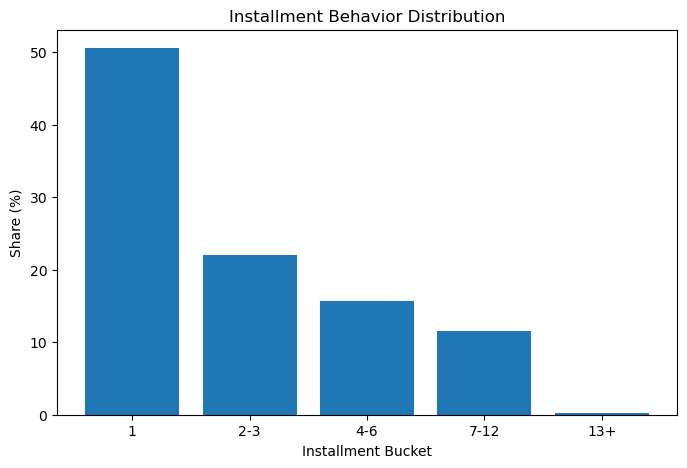

In [390]:
plt.figure(figsize=(8,5))
plt.bar(check["installment_bucket"], check["share_pct"])
plt.xlabel("Installment Bucket")
plt.ylabel("Share (%)")
plt.title("Installment Behavior Distribution")
plt.show()

In [438]:
# Purchase Time (Hour) vs Orders
query = """WITH base AS (
SELECT CASE
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 0 AND 3 THEN '00-04 Late Night'
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 4 AND 7 THEN '04-08 Early Morning'
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 8 AND 11 THEN '08-12 Mid-Morning'
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 12 AND 15 THEN '12-16 Afternoon'
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 16 AND 19 THEN '16-20 Evening'
ELSE '20-24 Night'
END AS time_bucket
FROM olist_orders_dataset )
SELECT time_bucket, COUNT(*) AS total_orders
FROM base
GROUP BY time_bucket
ORDER BY time_bucket;"""
check = pd.read_sql(query, engine)
check

,time_bucket,total_orders
0,00-04 Late Night,4346
1,04-08 Early Morning,2127
2,08-12 Mid-Morning,20507
3,12-16 Afternoon,25536
4,16-20 Evening,24576
5,20-24 Night,22349
